# 1. Data Filtering

In [186]:
import pandas as pd
from tqdm import tqdm
import numpy as np
import seaborn as sns
from IPython.display import Image
import matplotlib.pyplot as plt
import os
import pickle as pkl

# Libraries from differential Expression Analysis
import conorm
import plotly.express as px
import plotly.offline as pyo

In [187]:
count_matrix = pd.read_csv('/12tb_dsk2/common_data/ROSMAP_DATA/ROSMAP_all_counts_matrix.txt',sep = '\t',index_col=0)

In [188]:
count_matrix = count_matrix.iloc[4:]
count_matrix

,01_120405,02_120405,03_120405,04_120405,05_120405,07_120410,08_120410,100_120417,101_120418,102_120418,...,952_131107,954_131107,956_131107,957_131107,958_131107,96_120417,97_120417,98_120417,R24_131017,redo4_140501
feature,,,,,,,,,,,,,,,,,,,,,
ENSG00000223972.5,1,1,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000227232.5,99,174,78,188,56,81,87,157,136,102,...,83,188,256,91,413,93,98,171,236,322
ENSG00000278267.1,2,5,5,4,2,1,1,2,2,4,...,0,6,4,3,10,0,1,7,3,8
ENSG00000243485.3,0,5,2,5,3,0,0,0,0,3,...,3,0,0,6,2,1,2,2,2,2
ENSG00000274890.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000277374.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000278806.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000274152.1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [189]:
index = [i.split('.')[0] for i in count_matrix.reset_index()['feature'].tolist()]


In [190]:
count_matrix.index = index

In [191]:
count_matrix.head()

,01_120405,02_120405,03_120405,04_120405,05_120405,07_120410,08_120410,100_120417,101_120418,102_120418,...,952_131107,954_131107,956_131107,957_131107,958_131107,96_120417,97_120417,98_120417,R24_131017,redo4_140501
ENSG00000223972,1,1,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000227232,99,174,78,188,56,81,87,157,136,102,...,83,188,256,91,413,93,98,171,236,322
ENSG00000278267,2,5,5,4,2,1,1,2,2,4,...,0,6,4,3,10,0,1,7,3,8
ENSG00000243485,0,5,2,5,3,0,0,0,0,3,...,3,0,0,6,2,1,2,2,2,2
ENSG00000274890,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [192]:

biospecimen_metadata = pd.read_csv('/12tb_dsk2/common_data/ROSMAP_DATA/ROSMAP_biospecimen_metadata.csv')
clinical_data = pd.read_csv('/12tb_dsk2/common_data/ROSMAP_DATA/RSP_CL.csv')
rna_seq_metadata = pd.read_csv('/12tb_dsk2/common_data/ROSMAP_DATA/ROSMAP_assay_rnaSeq_metadata.csv')


In [193]:
biospecimen_metadata = biospecimen_metadata[biospecimen_metadata.assay == 'rnaSeq' ]
biospecimen_metadata = biospecimen_metadata[biospecimen_metadata.nucleicAcidSource == 'bulk cell' ]
biospecimen_metadata = biospecimen_metadata[biospecimen_metadata.tissue == 'dorsolateral prefrontal cortex' ]
biospecimen_metadata = biospecimen_metadata[~biospecimen_metadata.individualID.isna()  ]

biospecimen_metadata

,individualID,specimenID,specimenIdSource,organ,tissue,BrodmannArea,sampleStatus,tissueWeight,tissueVolume,nucleicAcidSource,cellType,fastingState,isPostMortem,samplingAge,samplingAgeUnits,visitNumber,assay,exclude,excludeReason,samplingDate
1916,R9976232,510_120515,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,NaN,NaN,NaN
1917,R9936070,207_120424,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,NaN,NaN,NaN
1918,R9907075,81_120417,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,NaN,NaN,NaN
1919,R9905342,649_120529,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,NaN,NaN,NaN
1920,R9904978,487_120515,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10157,R6796261,Sample_R6796261-DLPFC,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,True,sample swap,NaN
10158,R7310856,Sample_200r1-DLPFC,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,True,sample swap,NaN
10159,R3824126,Sample_R3824126-DLPFC,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,True,sample swap,NaN
10160,R7559268,Sample_R7559268-DLPFC,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,True,sample swap,NaN


In [194]:
specimenID = count_matrix.columns.values[1:]

In [195]:
biospecimen_metadata = biospecimen_metadata[biospecimen_metadata.specimenID.isin(specimenID)]


In [196]:
biospecimen_metadata[biospecimen_metadata.specimenID.isin(['316_120501','764_130520','791_130530','800_130701','380_120503', '500_120515'])]


,individualID,specimenID,specimenIdSource,organ,tissue,BrodmannArea,sampleStatus,tissueWeight,tissueVolume,nucleicAcidSource,cellType,fastingState,isPostMortem,samplingAge,samplingAgeUnits,visitNumber,assay,exclude,excludeReason,samplingDate
2009,R8432213,316_120501,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,NaN,NaN,NaN
2120,R6531744,380_120503,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,NaN,NaN,NaN
2199,R5211056,500_120515,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,NaN,NaN,NaN
3856,R4637403,791_130530,NaN,brain,dorsolateral prefrontal cortex,NaN,NaN,NaN,NaN,bulk cell,NaN,NaN,NaN,NaN,NaN,NaN,rnaSeq,NaN,NaN,NaN


In [197]:
def return_specimenid(indvidualid):
    
    x = biospecimen_metadata[biospecimen_metadata.individualID == indvidualid]['specimenID'].values
    try:
        return x[0]
    except:
        return np.nan

In [198]:
clinical_data['specimenID'] = clinical_data.individualID.apply(return_specimenid)
clinical_data

,projid,Study,msex,educ,race,spanish,apoe_genotype,age_at_visit_max,age_first_ad_dx,age_death,cts_mmse30_first_ad_dx,cts_mmse30_lv,pmi,braaksc,ceradsc,cogdx,dcfdx_lv,individualID,specimenID
0,10101589,ROS,1.0,20.0,1.0,2.0,34.0,90+,90+,90+,18.0,5.0,9.916667,4.0,2.0,4.0,4.0,R6939144,594_120522
1,86767530,MAP,0.0,10.0,1.0,2.0,33.0,90+,90+,90+,18.0,10.0,6.500000,4.0,2.0,4.0,4.0,R3893503,NaN
2,9650662,MAP,0.0,15.0,1.0,2.0,23.0,90+,90+,90+,0.0,0.0,3.850000,3.0,2.0,4.0,4.0,R8937093,565_120517
3,50402855,MAP,0.0,21.0,1.0,2.0,33.0,90+,NaN,NaN,NaN,27.0,NaN,NaN,NaN,NaN,1.0,R7139444,NaN
4,20544321,ROS,0.0,16.0,1.0,2.0,23.0,90+,90+,NaN,13.0,14.0,NaN,NaN,NaN,NaN,4.0,R4971237,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3579,22207815,ROS,0.0,18.0,2.0,2.0,23.0,57.653661875427787,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,1.0,R5306025,NaN
3580,22207941,ROS,0.0,16.0,2.0,2.0,34.0,56.651608487337441,NaN,NaN,NaN,27.0,NaN,NaN,NaN,NaN,1.0,R6142763,NaN
3581,49333806,MAP,0.0,12.0,2.0,2.0,NaN,56.599589322381931,NaN,NaN,NaN,30.0,NaN,NaN,NaN,NaN,1.0,R4468842,NaN
3582,59720188,MAP,0.0,13.0,1.0,1.0,NaN,54.622861054072551,NaN,NaN,NaN,29.0,NaN,NaN,NaN,NaN,1.0,R9446033,NaN


In [199]:
clinical_data = clinical_data[~clinical_data['specimenID'].isna()]
clinical_data

,projid,Study,msex,educ,race,spanish,apoe_genotype,age_at_visit_max,age_first_ad_dx,age_death,cts_mmse30_first_ad_dx,cts_mmse30_lv,pmi,braaksc,ceradsc,cogdx,dcfdx_lv,individualID,specimenID
0,10101589,ROS,1.0,20.0,1.0,2.0,34.0,90+,90+,90+,18.0,5.000000,9.916667,4.0,2.0,4.0,4.0,R6939144,594_120522
2,9650662,MAP,0.0,15.0,1.0,2.0,23.0,90+,90+,90+,0.0,0.000000,3.850000,3.0,2.0,4.0,4.0,R8937093,565_120517
5,20630946,ROS,0.0,18.0,1.0,2.0,33.0,90+,90+,90+,NaN,0.000000,2.900000,3.0,4.0,4.0,4.0,R4859661,255_120426
9,10433070,ROS,1.0,13.0,1.0,2.0,23.0,90+,90+,90+,18.0,8.000000,3.500000,4.0,2.0,5.0,4.0,R1158585,51_120416
13,20969088,ROS,0.0,18.0,1.0,2.0,33.0,90+,NaN,90+,NaN,23.000000,9.916667,4.0,2.0,2.0,2.0,R2397348,227_120425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3410,20656964,ROS,0.0,18.0,1.0,2.0,33.0,71.227926078028744,NaN,71.310061601642715,NaN,29.000000,7.800000,3.0,2.0,1.0,2.0,R8704458,242_120426
3432,11615242,ROS,1.0,10.0,1.0,2.0,33.0,70.510609171800141,NaN,71.66050650239562,NaN,28.928571,5.433333,0.0,4.0,1.0,1.0,R7039412,483_120515
3456,11413170,ROS,1.0,18.0,1.0,2.0,23.0,69.733059548254616,NaN,70.269678302532512,NaN,5.000000,8.250000,3.0,4.0,5.0,5.0,R3769291,190_120424
3498,24039289,MAP,1.0,18.0,1.0,2.0,23.0,68.440793976728273,NaN,72.147843942505133,NaN,26.000000,5.833333,2.0,4.0,2.0,2.0,R7334123,394_120503


In [200]:
clinical_data[clinical_data.specimenID.isin(['316_120501','764_130520','791_130530','800_130701'])]

,projid,Study,msex,educ,race,spanish,apoe_genotype,age_at_visit_max,age_first_ad_dx,age_death,cts_mmse30_first_ad_dx,cts_mmse30_lv,pmi,braaksc,ceradsc,cogdx,dcfdx_lv,individualID,specimenID
253,21156815,ROS,0.0,22.0,1.0,2.0,33.0,90+,87.154004106776185,90+,28.0,1.0,NaN,5.0,1.0,4.0,4.0,R8432213,316_120501
1683,91444029,MAP,1.0,16.0,1.0,2.0,33.0,86.98699520876113,NaN,87.687885010266939,NaN,17.0,5.8,3.0,2.0,4.0,4.0,R4637403,791_130530


In [201]:
count_matrix = count_matrix.drop(columns = ['316_120501','764_130520','791_130530','800_130701','380_120503', '500_120515'])
count_matrix_raw = count_matrix.copy()
count_matrix_raw

,01_120405,02_120405,03_120405,04_120405,05_120405,07_120410,08_120410,100_120417,101_120418,102_120418,...,952_131107,954_131107,956_131107,957_131107,958_131107,96_120417,97_120417,98_120417,R24_131017,redo4_140501
ENSG00000223972,1,1,1,0,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000227232,99,174,78,188,56,81,87,157,136,102,...,83,188,256,91,413,93,98,171,236,322
ENSG00000278267,2,5,5,4,2,1,1,2,2,4,...,0,6,4,3,10,0,1,7,3,8
ENSG00000243485,0,5,2,5,3,0,0,0,0,3,...,3,0,0,6,2,1,2,2,2,2
ENSG00000274890,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000277374,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000278806,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000274152,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000276666,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [202]:
import pickle
with open('/12tb_dsk2/danish/Gene_Regulatory_Network_ROSMAP/code/clinical_data_pickle//NCI_with_No_Plaques.pkl','rb') as f:
    NCI_with_No_Plaques= pickle.load(f)

with open('/12tb_dsk2/danish/Gene_Regulatory_Network_ROSMAP/code/clinical_data_pickle/AD_with_Plaques.pkl','rb') as f:
    AD_with_Plaques= pickle.load(f)

with open('/12tb_dsk2/danish/Gene_Regulatory_Network_ROSMAP/code/clinical_data_pickle/AD_with_No_Plaques.pkl','rb') as f:
    AD_with_No_Plaques= pickle.load(f)

with open('/12tb_dsk2/danish/Gene_Regulatory_Network_ROSMAP/code/clinical_data_pickle/NCI_with_Plaques.pkl','rb') as f:
    NCI_with_Plaques = pickle.load(f)

In [203]:
print(clinical_data[clinical_data.specimenID.isin(AD_with_Plaques)].cogdx.value_counts())
print(clinical_data[clinical_data.specimenID.isin(AD_with_Plaques)].ceradsc.value_counts())

cogdx
4.0    111
Name: count, dtype: int64
ceradsc
1.0    111
Name: count, dtype: int64


In [204]:
print(clinical_data[clinical_data.specimenID.isin(NCI_with_No_Plaques)].cogdx.value_counts())
print(clinical_data[clinical_data.specimenID.isin(NCI_with_No_Plaques)].ceradsc.value_counts())

cogdx
1.0    78
Name: count, dtype: int64
ceradsc
4.0    78
Name: count, dtype: int64


In [205]:
AD_with_Plaques.remove('500_120515')

In [206]:
df_AD_with_Plaques=  count_matrix_raw[AD_with_Plaques]
df_NCI_with_no_Plaques=  count_matrix_raw[NCI_with_No_Plaques]

In [207]:
df_AD_with_Plaques

,23_120411,591_120522,943_131101,604_120523,545_120516,364_120502,705_120605,711_120531,602_120523,229_120425,...,847_130830,424_120507,420_120507,193_120424,649_120529,689_120604,942_131101,929_131031,628_120524,721_120531
ENSG00000223972,0,0,0,0,0,0,1,0,0,0,...,0,1,0,0,0,0,0,0,0,1
ENSG00000227232,122,127,252,502,86,111,126,150,210,92,...,160,116,160,211,134,191,137,94,93,86
ENSG00000278267,7,5,8,16,4,4,3,9,11,1,...,2,6,2,6,9,3,2,0,1,3
ENSG00000243485,0,0,1,1,1,0,1,0,3,0,...,2,2,1,3,1,5,1,0,0,0
ENSG00000274890,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000277374,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000278806,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000274152,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ENSG00000276666,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [208]:
from bioinfokit.analys import norm
from rnanorm import CPM
df_AD_with_Plaques.T.head() # this should be input for rnanorm package

,ENSG00000223972,ENSG00000227232,ENSG00000278267,ENSG00000243485,ENSG00000274890,ENSG00000237613,ENSG00000268020,ENSG00000240361,ENSG00000186092,ENSG00000238009,...,ENSG00000278241,ENSG00000276207,ENSG00000278015,ENSG00000278625,ENSG00000274938,ENSG00000277374,ENSG00000278806,ENSG00000274152,ENSG00000276666,ENSG00000277917
23_120411,0,122,7,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
591_120522,0,127,5,0,0,0,0,0,0,2,...,0,0,0,0,0,0,0,0,0,0
943_131101,0,252,8,1,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
604_120523,0,502,16,1,0,0,0,1,0,3,...,0,1,0,1,0,0,0,0,0,0
545_120516,0,86,4,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [209]:
df_AD_with_Plaques_normalized = CPM().set_output(transform="pandas").fit_transform(df_AD_with_Plaques.T)
df_AD_with_Plaques_normalized  = df_AD_with_Plaques_normalized.T
df_AD_with_Plaques_normalized.head()

,23_120411,591_120522,943_131101,604_120523,545_120516,364_120502,705_120605,711_120531,602_120523,229_120425,...,847_130830,424_120507,420_120507,193_120424,649_120529,689_120604,942_131101,929_131031,628_120524,721_120531
ENSG00000223972,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.044176,0.000000,0.000000,0.000000,...,0.000000,0.062260,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.064179
ENSG00000227232,5.990638,4.608170,8.555069,14.547470,5.578616,4.949715,5.566136,6.046737,6.157311,5.410985,...,4.959084,7.222132,7.239035,9.379610,5.321935,7.089032,6.660413,4.663577,5.495294,5.519403
ENSG00000278267,0.343725,0.181424,0.271589,0.463664,0.259470,0.178368,0.132527,0.362804,0.322526,0.058815,...,0.061989,0.373559,0.090488,0.266719,0.357443,0.111346,0.097232,0.000000,0.059089,0.192537
ENSG00000243485,0.000000,0.000000,0.033949,0.028979,0.064868,0.000000,0.044176,0.000000,0.087962,0.000000,...,0.061989,0.124520,0.045244,0.133359,0.039716,0.185577,0.048616,0.000000,0.000000,0.000000
ENSG00000274890,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [210]:
df_AD_with_Plaques.shape

(60725, 110)

In [211]:
df_AD_with_Plaques = df_AD_with_Plaques[(df_AD_with_Plaques_normalized >= 1).astype(int).sum(axis=1)>= 110/2]
df_AD_with_Plaques.shape

(17019, 110)

In [212]:
df_NCI_with_no_Plaques_normalized = CPM().set_output(transform="pandas").fit_transform(df_NCI_with_no_Plaques.T)
df_NCI_with_no_Plaques_normalized  = df_NCI_with_no_Plaques_normalized.T
df_NCI_with_no_Plaques_normalized.head()

,691_120605,588_120522,680_120604,274_120430,713_120531,460_120514,04_120405,824_130725,285_120430,647_120529,...,882_130918,587_120522,168_120423,954_131107,283_120430,677_120604,142_120419,120_120418,483_120515,174_120424
ENSG00000223972,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.032671,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ENSG00000227232,7.219198,7.683564,5.873398,6.501366,8.919565,9.152574,7.536497,7.020897,7.542386,7.686426,...,11.402088,6.570028,7.989085,6.747660,6.300419,3.029851,4.778706,4.298759,8.662088,4.336108
ENSG00000278267,0.000000,0.232835,0.364556,0.041148,0.196034,0.186154,0.160351,0.000000,0.126409,0.313732,...,0.490061,0.084775,0.297466,0.215351,0.183954,0.049670,0.251511,0.174746,0.310593,0.151612
ENSG00000243485,0.036646,0.155224,0.040506,0.123444,0.032672,0.031026,0.200439,0.118998,0.042136,0.125493,...,0.163354,0.042387,0.212476,0.000000,0.091977,0.099339,0.000000,0.034949,0.103531,0.060645
ENSG00000274890,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [213]:
df_NCI_with_no_Plaques = df_NCI_with_no_Plaques_normalized[(df_NCI_with_no_Plaques_normalized >= 1).astype(int).sum(axis=1)>= 78/2]
df_NCI_with_no_Plaques.shape

(17180, 78)

In [214]:
keep_index = set(df_NCI_with_no_Plaques.index).union(set(df_AD_with_Plaques.index))

In [215]:
count_matrix_raw = count_matrix_raw.loc[list(keep_index),:]
count_matrix_raw

,01_120405,02_120405,03_120405,04_120405,05_120405,07_120410,08_120410,100_120417,101_120418,102_120418,...,952_131107,954_131107,956_131107,957_131107,958_131107,96_120417,97_120417,98_120417,R24_131017,redo4_140501
ENSG00000115282,169,289,166,297,145,140,209,246,290,201,...,204,286,344,172,561,201,242,226,544,596
ENSG00000239305,441,777,358,649,308,312,337,323,657,441,...,590,685,1028,551,995,260,440,380,1435,1194
ENSG00000174827,22,35,26,32,20,11,33,25,22,17,...,28,24,20,35,32,26,10,24,39,35
ENSG00000256422,6,93,47,65,12,22,5,23,41,50,...,20,28,20,61,33,5,24,28,32,144
ENSG00000066933,1109,1933,1139,1813,988,1122,1239,1055,1581,1399,...,1894,555,706,2093,716,936,1625,1132,1094,923
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000103657,1140,3924,1771,3836,1249,1267,1018,1689,2791,3400,...,2902,1699,2118,3234,2966,945,1588,2093,5194,4859
ENSG00000011105,258,771,297,613,215,296,269,438,621,601,...,391,507,800,570,865,248,347,442,823,761
ENSG00000129515,590,625,263,527,265,280,387,296,437,505,...,736,997,929,627,1077,332,449,346,1105,1283
ENSG00000214174,319,726,448,673,298,347,449,317,550,616,...,574,647,1113,688,1059,327,461,462,1575,1898


In [216]:
count_matrix_raw.loc['ENSG00000153130','01_120405']

867

In [217]:
count_matrix_raw = count_matrix_raw[AD_with_Plaques+NCI_with_No_Plaques] 
count_matrix_raw

,23_120411,591_120522,943_131101,604_120523,545_120516,364_120502,705_120605,711_120531,602_120523,229_120425,...,882_130918,587_120522,168_120423,954_131107,283_120430,677_120604,142_120419,120_120418,483_120515,174_120424
ENSG00000115282,305,323,478,331,201,258,264,260,350,134,...,547,233,252,286,155,165,186,267,248,283
ENSG00000239305,451,709,910,816,274,471,478,467,896,249,...,861,411,488,685,445,275,412,444,610,487
ENSG00000174827,28,35,31,39,17,36,20,33,33,18,...,22,16,20,24,26,16,23,44,32,18
ENSG00000256422,36,45,47,61,22,20,11,22,57,42,...,45,20,48,28,41,13,15,22,101,19
ENSG00000066933,1313,2103,871,2207,750,1354,1058,1236,2575,945,...,970,1263,1610,555,1295,768,1279,1429,2158,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000103657,2669,3430,3968,4826,1200,2281,2123,2015,5089,1206,...,3685,2057,4421,1699,2437,1204,2590,1849,5068,1693
ENSG00000011105,618,762,670,749,295,452,471,541,860,347,...,614,350,808,507,516,336,331,558,885,524
ENSG00000129515,472,712,986,822,318,539,486,553,775,201,...,1082,367,508,997,341,392,431,655,648,658
ENSG00000214174,491,702,1401,879,350,555,481,395,902,283,...,1330,379,655,647,497,259,536,498,735,507


In [218]:
!mkdir data_preprocessed

mkdir: cannot create directory ‘data_preprocessed’: File exists


In [219]:
!mkdir data_preprocessed/count_matrix_preprocessed

mkdir: cannot create directory ‘data_preprocessed/count_matrix_preprocessed’: File exists


In [220]:
count_matrix_raw.to_csv('data_preprocessed/count_matrix_preprocessed/1_count_matrix_raw_AD_NCI.csv')

In [221]:
count_matrix_raw = pd.read_csv('data_preprocessed/count_matrix_preprocessed/1_count_matrix_raw_AD_NCI.csv', index_col=0)
count_matrix_raw

,23_120411,591_120522,943_131101,604_120523,545_120516,364_120502,705_120605,711_120531,602_120523,229_120425,...,882_130918,587_120522,168_120423,954_131107,283_120430,677_120604,142_120419,120_120418,483_120515,174_120424
ENSG00000115282,305,323,478,331,201,258,264,260,350,134,...,547,233,252,286,155,165,186,267,248,283
ENSG00000239305,451,709,910,816,274,471,478,467,896,249,...,861,411,488,685,445,275,412,444,610,487
ENSG00000174827,28,35,31,39,17,36,20,33,33,18,...,22,16,20,24,26,16,23,44,32,18
ENSG00000256422,36,45,47,61,22,20,11,22,57,42,...,45,20,48,28,41,13,15,22,101,19
ENSG00000066933,1313,2103,871,2207,750,1354,1058,1236,2575,945,...,970,1263,1610,555,1295,768,1279,1429,2158,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000103657,2669,3430,3968,4826,1200,2281,2123,2015,5089,1206,...,3685,2057,4421,1699,2437,1204,2590,1849,5068,1693
ENSG00000011105,618,762,670,749,295,452,471,541,860,347,...,614,350,808,507,516,336,331,558,885,524
ENSG00000129515,472,712,986,822,318,539,486,553,775,201,...,1082,367,508,997,341,392,431,655,648,658
ENSG00000214174,491,702,1401,879,350,555,481,395,902,283,...,1330,379,655,647,497,259,536,498,735,507


# 2. Covariates effect Check

In [222]:
count_matrix_cpm = CPM().set_output(transform="pandas").fit_transform(count_matrix_raw.T)
count_matrix_cpm  = count_matrix_cpm.T
count_matrix_cpm.head()

,23_120411,591_120522,943_131101,604_120523,545_120516,364_120502,705_120605,711_120531,602_120523,229_120425,...,882_130918,587_120522,168_120423,954_131107,283_120430,677_120604,142_120419,120_120418,483_120515,174_120424
ENSG00000115282,15.050807,11.778160,16.284164,9.640409,13.106721,11.563396,11.711346,10.522859,10.313575,7.916971,...,17.932029,9.922227,10.760444,10.291802,7.158734,8.225126,9.404054,9.380847,8.601310,8.618968
ENSG00000239305,22.255456,25.853608,31.001233,23.766084,17.866873,21.109920,21.204633,18.900673,26.402752,14.711387,...,28.225735,17.502297,20.837686,24.649945,20.552494,13.708543,20.830484,15.599610,21.156447,14.831934
ENSG00000174827,1.381713,1.276271,1.056086,1.135879,1.108529,1.613497,0.887223,1.335594,0.972423,1.063474,...,0.721215,0.681355,0.854004,0.863648,1.200820,0.797588,1.162867,1.545907,1.109846,0.548203
ENSG00000256422,1.776489,1.640920,1.601163,1.776631,1.434566,0.896387,0.487973,0.890396,1.679639,2.481439,...,1.475213,0.851693,2.049608,1.007589,1.893601,0.648040,0.758391,0.772954,3.502953,0.578659
ENSG00000066933,64.792491,76.685668,29.672609,64.279101,48.905674,60.685418,46.934105,50.024051,75.878443,55.832371,...,31.799028,53.784431,68.747284,19.971853,59.810065,38.284223,64.665508,50.206853,74.845266,44.160789


In [223]:
count_matrix_cpm = count_matrix_cpm.T
count_matrix_cpm.head()

,ENSG00000115282,ENSG00000239305,ENSG00000174827,ENSG00000256422,ENSG00000066933,ENSG00000108379,ENSG00000174437,ENSG00000078304,ENSG00000101443,ENSG00000204217,...,ENSG00000165591,ENSG00000113532,ENSG00000151892,ENSG00000102100,ENSG00000279765,ENSG00000103657,ENSG00000011105,ENSG00000129515,ENSG00000214174,ENSG00000235944
23_120411,15.050807,22.255456,1.381713,1.776489,64.792491,16.975337,347.648970,84.777989,6.908567,67.654612,...,1.283020,4.046446,25.857780,13.521053,0.690857,131.706899,30.496389,23.291741,24.229332,13.323665
591_120522,11.778160,25.853608,1.276271,1.640920,76.685668,15.096465,316.697588,94.115886,7.256514,79.347605,...,1.823245,4.703971,18.195981,13.382615,1.458596,125.074580,27.786248,25.963003,25.598354,13.564940
943_131101,16.284164,31.001233,1.056086,1.601163,29.672609,9.095966,325.308545,123.221385,5.212295,110.957161,...,2.589114,6.609054,52.599895,15.466549,0.681346,135.179004,22.825084,33.590347,47.728272,6.404650
604_120523,9.640409,23.766084,1.135879,1.776631,64.279101,23.620458,317.958745,101.850484,6.058021,81.404662,...,1.601881,5.184268,20.096321,12.931546,1.718381,140.557745,21.814702,23.940834,25.600965,13.339297
545_120516,13.106721,17.866873,1.108529,1.434566,48.905674,6.651172,141.826453,58.686808,5.412228,41.341596,...,1.695397,4.825360,15.128155,9.911550,1.173736,78.249078,19.236232,20.736006,22.822648,12.063399


In [224]:
rna_seq_metadata = rna_seq_metadata[rna_seq_metadata.specimenID.isin(specimenID)]

### 2.1 Batch 

In [225]:
def return_batch(feature):
    try:
    
        return int(rna_seq_metadata[rna_seq_metadata.specimenID == feature]['libraryBatch'].values[0])
    except:
        return 0

In [226]:
m = list(map(return_batch,count_matrix_raw.T.index.tolist()))
print(m[0:20])

[6, 2, 7, 2, 4, 5, 3, 3, 2, 4, 7, 3, 2, 4, 1, 7, 6, 1, 6, 7]


In [227]:
rna_seq_metadata[rna_seq_metadata.specimenID == '943_131101']['libraryBatch'].values[0]

'7'

In [228]:
count_matrix_raw.T

,ENSG00000115282,ENSG00000239305,ENSG00000174827,ENSG00000256422,ENSG00000066933,ENSG00000108379,ENSG00000174437,ENSG00000078304,ENSG00000101443,ENSG00000204217,...,ENSG00000165591,ENSG00000113532,ENSG00000151892,ENSG00000102100,ENSG00000279765,ENSG00000103657,ENSG00000011105,ENSG00000129515,ENSG00000214174,ENSG00000235944
23_120411,305,451,28,36,1313,344,7045,1718,140,1371,...,26,82,524,274,14,2669,618,472,491,270
591_120522,323,709,35,45,2103,414,8685,2581,199,2176,...,50,129,499,367,40,3430,762,712,702,372
943_131101,478,910,31,47,871,267,9549,3617,153,3257,...,76,194,1544,454,20,3968,670,986,1401,188
604_120523,331,816,39,61,2207,811,10917,3497,208,2795,...,55,178,690,444,59,4826,749,822,879,458
545_120516,201,274,17,22,750,102,2175,900,83,634,...,26,74,232,152,18,1200,295,318,350,185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,165,275,16,13,768,87,3075,1159,45,914,...,16,53,438,126,32,1204,336,392,259,125
142_120419,186,412,23,15,1279,173,6775,1962,57,1536,...,18,81,229,288,18,2590,331,431,536,177
120_120418,267,444,44,22,1429,100,3030,1472,87,1076,...,29,66,464,186,58,1849,558,655,498,294
483_120515,248,610,32,101,2158,535,15819,3181,218,3048,...,54,135,546,485,39,5068,885,648,735,450


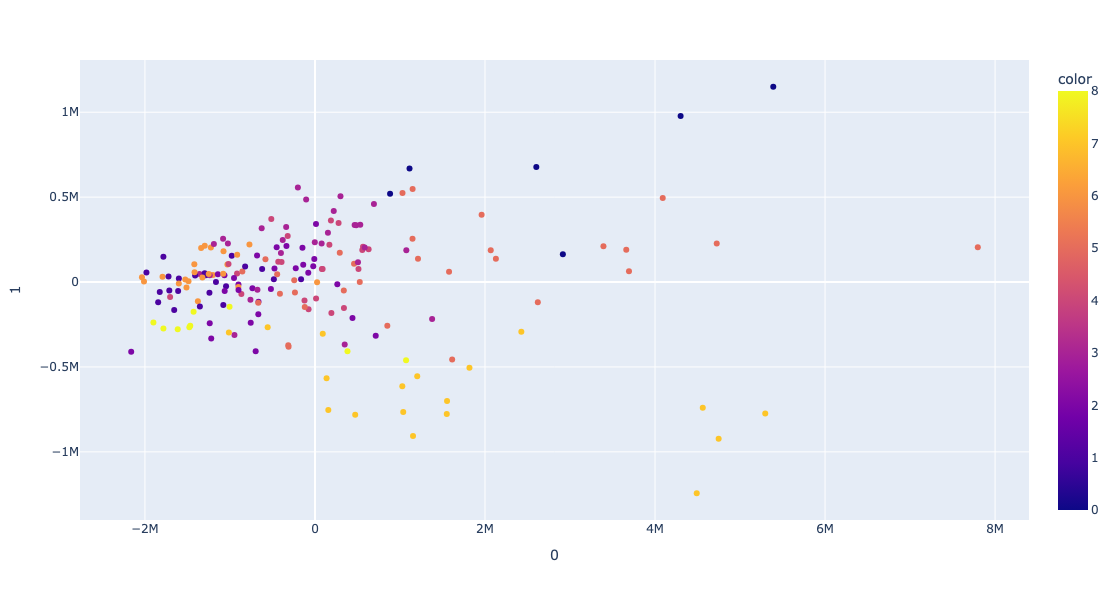

In [229]:
import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)

# Fit the PCA and transform the data
components = pca.fit_transform(count_matrix_raw.T)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=m)

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()


In [230]:
m[0:5]

[6, 2, 7, 2, 4]

### 2.2 Sex

In [231]:
def return_sex(feature):
    try:
    
        return int(clinical_data[clinical_data.specimenID == feature]['msex'].values[0])
    except:
        return 0

In [232]:
count_matrix_raw

,23_120411,591_120522,943_131101,604_120523,545_120516,364_120502,705_120605,711_120531,602_120523,229_120425,...,882_130918,587_120522,168_120423,954_131107,283_120430,677_120604,142_120419,120_120418,483_120515,174_120424
ENSG00000115282,305,323,478,331,201,258,264,260,350,134,...,547,233,252,286,155,165,186,267,248,283
ENSG00000239305,451,709,910,816,274,471,478,467,896,249,...,861,411,488,685,445,275,412,444,610,487
ENSG00000174827,28,35,31,39,17,36,20,33,33,18,...,22,16,20,24,26,16,23,44,32,18
ENSG00000256422,36,45,47,61,22,20,11,22,57,42,...,45,20,48,28,41,13,15,22,101,19
ENSG00000066933,1313,2103,871,2207,750,1354,1058,1236,2575,945,...,970,1263,1610,555,1295,768,1279,1429,2158,1450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000103657,2669,3430,3968,4826,1200,2281,2123,2015,5089,1206,...,3685,2057,4421,1699,2437,1204,2590,1849,5068,1693
ENSG00000011105,618,762,670,749,295,452,471,541,860,347,...,614,350,808,507,516,336,331,558,885,524
ENSG00000129515,472,712,986,822,318,539,486,553,775,201,...,1082,367,508,997,341,392,431,655,648,658
ENSG00000214174,491,702,1401,879,350,555,481,395,902,283,...,1330,379,655,647,497,259,536,498,735,507


In [233]:
m = list(map(return_sex,count_matrix_raw.T.index.tolist()))
print(m[0:20])

[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0]


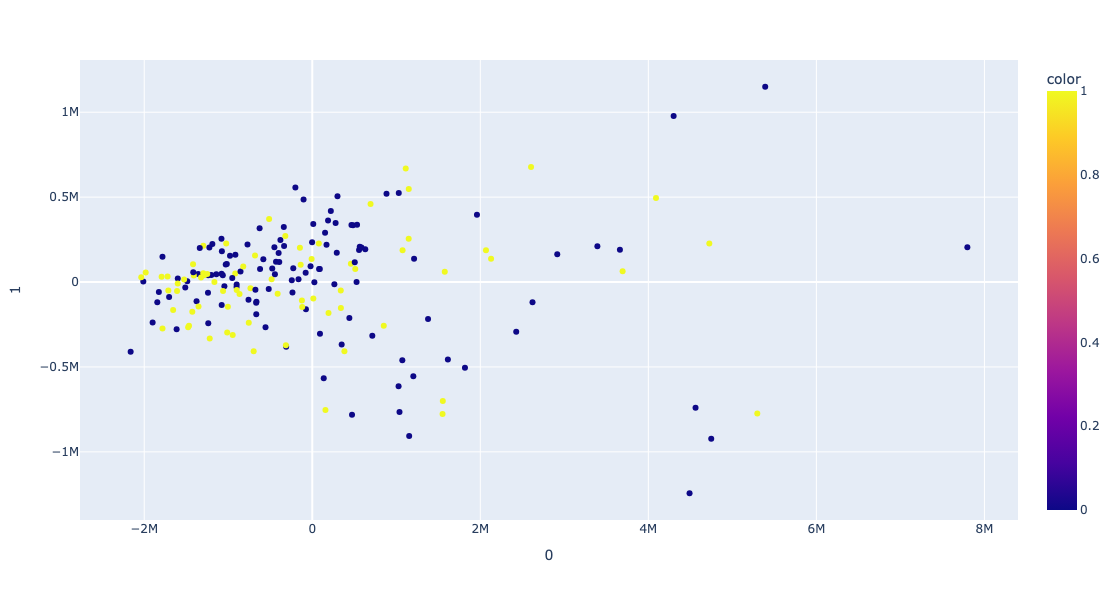

In [234]:
import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)

# Fit the PCA and transform the data
components = pca.fit_transform(count_matrix_raw.T)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=m)

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()


### 2.3 PMI

In [235]:
def return_pmi(feature):
    try:
    
        return int(clinical_data[clinical_data.specimenID == feature]['pmi'].values[0])
    except:
        return 0

In [236]:
m = list(map(return_pmi,count_matrix_raw.T.index.tolist()))
print(m[0:20])

[6, 5, 5, 17, 7, 19, 7, 8, 3, 12, 10, 6, 18, 7, 13, 23, 12, 5, 6, 10]


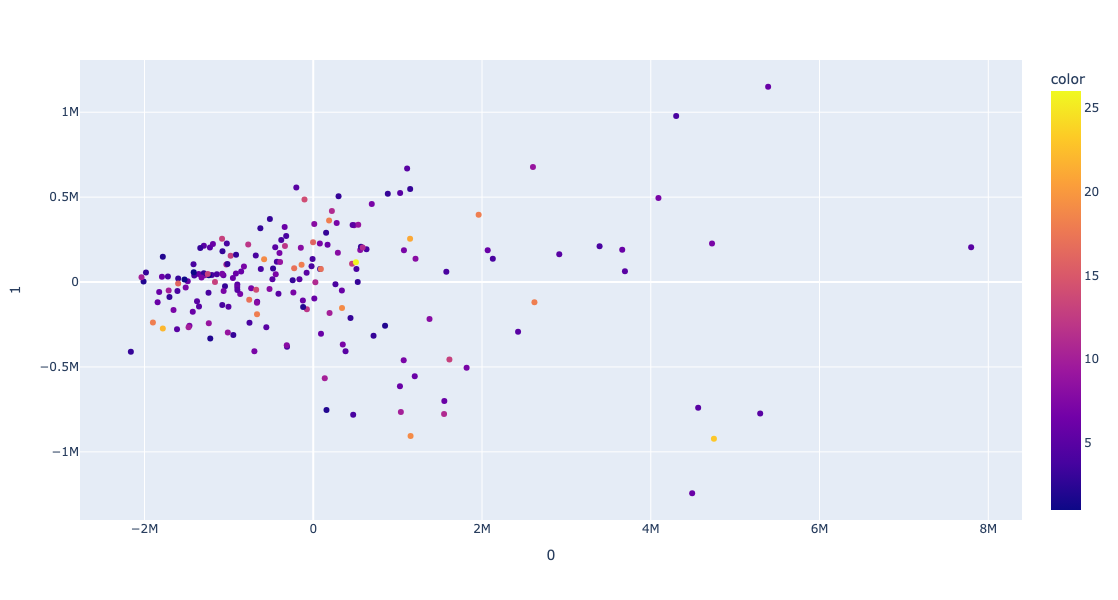

In [237]:
import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)

# Fit the PCA and transform the data
components = pca.fit_transform(count_matrix_raw.T)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=m)

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()


### 2.4 AD Diagnosis



In [238]:
def return_category(feature):
    if feature in AD_with_Plaques:
        return 'AD with Plaques'
    elif feature in NCI_with_No_Plaques:
        return 'NCI with No Plaques'

In [239]:
m = list(map(return_category,count_matrix_raw.T.index.tolist()))
print(m[0:20])

['AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques', 'AD with Plaques']


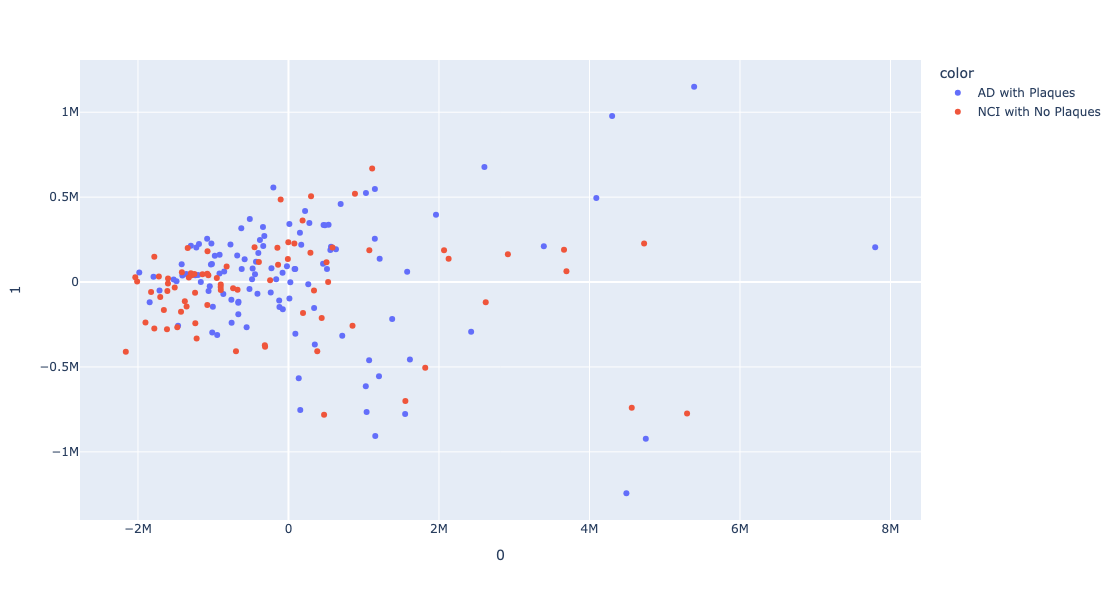

In [240]:
import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)

# Fit the PCA and transform the data
components = pca.fit_transform(count_matrix_raw.T)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=m)

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()


In [241]:
cols_include = ['Batch','educ','cogdx','race','pmi','age_at_visit_max','ceradsc','braaksc','specimenID','msex']

In [242]:
def return_category(feature):
    if feature in AD_with_Plaques:
        return 'AD with Plaques'
    elif feature in NCI_with_No_Plaques:
        return 'NCI with No Plaques'



clinical_data_AD_NCI = clinical_data[clinical_data.specimenID.isin(AD_with_Plaques+NCI_with_No_Plaques)]

clinical_data_AD_NCI['Category'] = clinical_data_AD_NCI.specimenID.apply(return_category)


/tmp/ipykernel_62296/4206225346.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [243]:
clinical_data_AD_NCI

,projid,Study,msex,educ,race,spanish,apoe_genotype,age_at_visit_max,age_first_ad_dx,age_death,cts_mmse30_first_ad_dx,cts_mmse30_lv,pmi,braaksc,ceradsc,cogdx,dcfdx_lv,individualID,specimenID,Category
30,50305165,MAP,0.0,18.0,1.0,2.0,33.0,90+,NaN,90+,NaN,4.137931,6.416667,4.0,1.0,4.0,4.0,R2859649,23_120411,AD with Plaques
32,7287209,MAP,0.0,12.0,1.0,2.0,33.0,90+,90+,90+,16.0,16.000000,5.200000,4.0,1.0,4.0,4.0,R6820248,591_120522,AD with Plaques
40,2525608,MAP,0.0,14.0,1.0,2.0,33.0,90+,NaN,90+,NaN,26.000000,4.833333,3.0,4.0,1.0,1.0,R6108690,691_120605,NCI with No Plaques
44,7265221,MAP,0.0,18.0,1.0,2.0,34.0,90+,90+,90+,23.0,14.000000,5.750000,4.0,1.0,4.0,4.0,R5629689,943_131101,AD with Plaques
58,20280666,ROS,0.0,18.0,1.0,2.0,33.0,90+,NaN,90+,NaN,27.600000,4.400000,4.0,4.0,1.0,1.0,R3368249,588_120522,NCI with No Plaques
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3382,20254164,ROS,0.0,23.0,1.0,2.0,33.0,71.720739219712527,NaN,71.958932238193015,NaN,29.000000,18.666667,3.0,4.0,1.0,1.0,R5935442,677_120604,NCI with No Plaques
3390,15712086,ROS,1.0,23.0,1.0,2.0,33.0,71.60301163586584,NaN,72.429842573579734,NaN,30.000000,7.000000,2.0,4.0,1.0,1.0,R1214999,142_120419,NCI with No Plaques
3398,10850171,ROS,1.0,26.0,1.0,2.0,33.0,71.482546201232026,NaN,71.624914442162904,NaN,30.000000,4.083333,1.0,4.0,1.0,1.0,R8935140,120_120418,NCI with No Plaques
3432,11615242,ROS,1.0,10.0,1.0,2.0,33.0,70.510609171800141,NaN,71.66050650239562,NaN,28.928571,5.433333,0.0,4.0,1.0,1.0,R7039412,483_120515,NCI with No Plaques


In [244]:
clinical_data_AD_NCI['Batch'] = clinical_data_AD_NCI.specimenID.apply(return_batch)

/tmp/ipykernel_62296/2048143227.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [245]:
clinical_data_AD_NCI.set_index('specimenID',inplace = True)

In [246]:
clinical_data_AD_NCI

,projid,Study,msex,educ,race,spanish,apoe_genotype,age_at_visit_max,age_first_ad_dx,age_death,cts_mmse30_first_ad_dx,cts_mmse30_lv,pmi,braaksc,ceradsc,cogdx,dcfdx_lv,individualID,Category,Batch
specimenID,,,,,,,,,,,,,,,,,,,,
23_120411,50305165,MAP,0.0,18.0,1.0,2.0,33.0,90+,NaN,90+,NaN,4.137931,6.416667,4.0,1.0,4.0,4.0,R2859649,AD with Plaques,6
591_120522,7287209,MAP,0.0,12.0,1.0,2.0,33.0,90+,90+,90+,16.0,16.000000,5.200000,4.0,1.0,4.0,4.0,R6820248,AD with Plaques,2
691_120605,2525608,MAP,0.0,14.0,1.0,2.0,33.0,90+,NaN,90+,NaN,26.000000,4.833333,3.0,4.0,1.0,1.0,R6108690,NCI with No Plaques,5
943_131101,7265221,MAP,0.0,18.0,1.0,2.0,34.0,90+,90+,90+,23.0,14.000000,5.750000,4.0,1.0,4.0,4.0,R5629689,AD with Plaques,7
588_120522,20280666,ROS,0.0,18.0,1.0,2.0,33.0,90+,NaN,90+,NaN,27.600000,4.400000,4.0,4.0,1.0,1.0,R3368249,NCI with No Plaques,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,20254164,ROS,0.0,23.0,1.0,2.0,33.0,71.720739219712527,NaN,71.958932238193015,NaN,29.000000,18.666667,3.0,4.0,1.0,1.0,R5935442,NCI with No Plaques,4
142_120419,15712086,ROS,1.0,23.0,1.0,2.0,33.0,71.60301163586584,NaN,72.429842573579734,NaN,30.000000,7.000000,2.0,4.0,1.0,1.0,R1214999,NCI with No Plaques,6
120_120418,10850171,ROS,1.0,26.0,1.0,2.0,33.0,71.482546201232026,NaN,71.624914442162904,NaN,30.000000,4.083333,1.0,4.0,1.0,1.0,R8935140,NCI with No Plaques,5


In [247]:
count_matrix_raw = count_matrix_raw.T
count_matrix_raw = count_matrix_raw.loc[clinical_data_AD_NCI.index,]
count_matrix_raw

,ENSG00000115282,ENSG00000239305,ENSG00000174827,ENSG00000256422,ENSG00000066933,ENSG00000108379,ENSG00000174437,ENSG00000078304,ENSG00000101443,ENSG00000204217,...,ENSG00000165591,ENSG00000113532,ENSG00000151892,ENSG00000102100,ENSG00000279765,ENSG00000103657,ENSG00000011105,ENSG00000129515,ENSG00000214174,ENSG00000235944
specimenID,,,,,,,,,,,,,,,,,,,,,
23_120411,305,451,28,36,1313,344,7045,1718,140,1371,...,26,82,524,274,14,2669,618,472,491,270
591_120522,323,709,35,45,2103,414,8685,2581,199,2176,...,50,129,499,367,40,3430,762,712,702,372
691_120605,381,638,33,49,2041,362,7019,2565,187,1894,...,58,112,566,302,27,3110,741,699,751,262
943_131101,478,910,31,47,871,267,9549,3617,153,3257,...,76,194,1544,454,20,3968,670,986,1401,188
588_120522,280,624,31,38,1760,324,8138,2377,124,1873,...,48,104,708,296,35,3585,655,523,606,260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,165,275,16,13,768,87,3075,1159,45,914,...,16,53,438,126,32,1204,336,392,259,125
142_120419,186,412,23,15,1279,173,6775,1962,57,1536,...,18,81,229,288,18,2590,331,431,536,177
120_120418,267,444,44,22,1429,100,3030,1472,87,1076,...,29,66,464,186,58,1849,558,655,498,294


In [248]:
clinical_data_AD_NCI.Batch.value_counts()

Batch
5    31
2    29
3    28
6    23
1    22
4    22
7    18
8     9
0     6
Name: count, dtype: int64

In [249]:
count_matrix_raw

,ENSG00000115282,ENSG00000239305,ENSG00000174827,ENSG00000256422,ENSG00000066933,ENSG00000108379,ENSG00000174437,ENSG00000078304,ENSG00000101443,ENSG00000204217,...,ENSG00000165591,ENSG00000113532,ENSG00000151892,ENSG00000102100,ENSG00000279765,ENSG00000103657,ENSG00000011105,ENSG00000129515,ENSG00000214174,ENSG00000235944
specimenID,,,,,,,,,,,,,,,,,,,,,
23_120411,305,451,28,36,1313,344,7045,1718,140,1371,...,26,82,524,274,14,2669,618,472,491,270
591_120522,323,709,35,45,2103,414,8685,2581,199,2176,...,50,129,499,367,40,3430,762,712,702,372
691_120605,381,638,33,49,2041,362,7019,2565,187,1894,...,58,112,566,302,27,3110,741,699,751,262
943_131101,478,910,31,47,871,267,9549,3617,153,3257,...,76,194,1544,454,20,3968,670,986,1401,188
588_120522,280,624,31,38,1760,324,8138,2377,124,1873,...,48,104,708,296,35,3585,655,523,606,260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,165,275,16,13,768,87,3075,1159,45,914,...,16,53,438,126,32,1204,336,392,259,125
142_120419,186,412,23,15,1279,173,6775,1962,57,1536,...,18,81,229,288,18,2590,331,431,536,177
120_120418,267,444,44,22,1429,100,3030,1472,87,1076,...,29,66,464,186,58,1849,558,655,498,294


In [250]:
count_matrix_raw.loc['23_120411','ENSG00000182870']

1865

In [251]:
clinical_data_AD_NCI.columns

Index(['projid', 'Study', 'msex', 'educ', 'race', 'spanish', 'apoe_genotype',
       'age_at_visit_max', 'age_first_ad_dx', 'age_death',
       'cts_mmse30_first_ad_dx', 'cts_mmse30_lv', 'pmi', 'braaksc', 'ceradsc',
       'cogdx', 'dcfdx_lv', 'individualID', 'Category', 'Batch'],
      dtype='object')

In [252]:
cols_include = ['Batch','educ','cogdx','race','pmi','age_at_visit_max','ceradsc','braaksc','msex','Category']

In [253]:
covariates_clinical_data_AD_NCI = clinical_data_AD_NCI[cols_include]

In [254]:
def return_float_age(feature):
    if '90+' in feature:
        return 90
    else:
        return feature
    
li_age = covariates_clinical_data_AD_NCI.age_at_visit_max.apply(return_float_age)

In [255]:
covariates_clinical_data_AD_NCI.age_at_visit_max = li_age

/tmp/ipykernel_62296/3678908590.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [256]:
count_matrix_raw

,ENSG00000115282,ENSG00000239305,ENSG00000174827,ENSG00000256422,ENSG00000066933,ENSG00000108379,ENSG00000174437,ENSG00000078304,ENSG00000101443,ENSG00000204217,...,ENSG00000165591,ENSG00000113532,ENSG00000151892,ENSG00000102100,ENSG00000279765,ENSG00000103657,ENSG00000011105,ENSG00000129515,ENSG00000214174,ENSG00000235944
specimenID,,,,,,,,,,,,,,,,,,,,,
23_120411,305,451,28,36,1313,344,7045,1718,140,1371,...,26,82,524,274,14,2669,618,472,491,270
591_120522,323,709,35,45,2103,414,8685,2581,199,2176,...,50,129,499,367,40,3430,762,712,702,372
691_120605,381,638,33,49,2041,362,7019,2565,187,1894,...,58,112,566,302,27,3110,741,699,751,262
943_131101,478,910,31,47,871,267,9549,3617,153,3257,...,76,194,1544,454,20,3968,670,986,1401,188
588_120522,280,624,31,38,1760,324,8138,2377,124,1873,...,48,104,708,296,35,3585,655,523,606,260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,165,275,16,13,768,87,3075,1159,45,914,...,16,53,438,126,32,1204,336,392,259,125
142_120419,186,412,23,15,1279,173,6775,1962,57,1536,...,18,81,229,288,18,2590,331,431,536,177
120_120418,267,444,44,22,1429,100,3030,1472,87,1076,...,29,66,464,186,58,1849,558,655,498,294


In [257]:
clinical_data_AD_NCI

,projid,Study,msex,educ,race,spanish,apoe_genotype,age_at_visit_max,age_first_ad_dx,age_death,cts_mmse30_first_ad_dx,cts_mmse30_lv,pmi,braaksc,ceradsc,cogdx,dcfdx_lv,individualID,Category,Batch
specimenID,,,,,,,,,,,,,,,,,,,,
23_120411,50305165,MAP,0.0,18.0,1.0,2.0,33.0,90+,NaN,90+,NaN,4.137931,6.416667,4.0,1.0,4.0,4.0,R2859649,AD with Plaques,6
591_120522,7287209,MAP,0.0,12.0,1.0,2.0,33.0,90+,90+,90+,16.0,16.000000,5.200000,4.0,1.0,4.0,4.0,R6820248,AD with Plaques,2
691_120605,2525608,MAP,0.0,14.0,1.0,2.0,33.0,90+,NaN,90+,NaN,26.000000,4.833333,3.0,4.0,1.0,1.0,R6108690,NCI with No Plaques,5
943_131101,7265221,MAP,0.0,18.0,1.0,2.0,34.0,90+,90+,90+,23.0,14.000000,5.750000,4.0,1.0,4.0,4.0,R5629689,AD with Plaques,7
588_120522,20280666,ROS,0.0,18.0,1.0,2.0,33.0,90+,NaN,90+,NaN,27.600000,4.400000,4.0,4.0,1.0,1.0,R3368249,NCI with No Plaques,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,20254164,ROS,0.0,23.0,1.0,2.0,33.0,71.720739219712527,NaN,71.958932238193015,NaN,29.000000,18.666667,3.0,4.0,1.0,1.0,R5935442,NCI with No Plaques,4
142_120419,15712086,ROS,1.0,23.0,1.0,2.0,33.0,71.60301163586584,NaN,72.429842573579734,NaN,30.000000,7.000000,2.0,4.0,1.0,1.0,R1214999,NCI with No Plaques,6
120_120418,10850171,ROS,1.0,26.0,1.0,2.0,33.0,71.482546201232026,NaN,71.624914442162904,NaN,30.000000,4.083333,1.0,4.0,1.0,1.0,R8935140,NCI with No Plaques,5


In [258]:
covariates_clinical_data_AD_NCI

,Batch,educ,cogdx,race,pmi,age_at_visit_max,ceradsc,braaksc,msex,Category
specimenID,,,,,,,,,,
23_120411,6,18.0,4.0,1.0,6.416667,90,1.0,4.0,0.0,AD with Plaques
591_120522,2,12.0,4.0,1.0,5.200000,90,1.0,4.0,0.0,AD with Plaques
691_120605,5,14.0,1.0,1.0,4.833333,90,4.0,3.0,0.0,NCI with No Plaques
943_131101,7,18.0,4.0,1.0,5.750000,90,1.0,4.0,0.0,AD with Plaques
588_120522,1,18.0,1.0,1.0,4.400000,90,4.0,4.0,0.0,NCI with No Plaques
...,...,...,...,...,...,...,...,...,...,...
677_120604,4,23.0,1.0,1.0,18.666667,71.720739219712527,4.0,3.0,0.0,NCI with No Plaques
142_120419,6,23.0,1.0,1.0,7.000000,71.60301163586584,4.0,2.0,1.0,NCI with No Plaques
120_120418,5,26.0,1.0,1.0,4.083333,71.482546201232026,4.0,1.0,1.0,NCI with No Plaques


In [259]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels =  covariates_clinical_data_AD_NCI.Batch.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = count_matrix_raw

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)


import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)


components = pca.fit_transform(count_matrix_raw)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=covariates_clinical_data_AD_NCI.Batch.tolist() )

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()

/tmp/ipykernel_62296/663210326.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



   PCA Component  F-statistic       P-value
0              1    23.345246  2.939497e-24
1              2    39.820253  6.247883e-36
2              3    13.667512  2.164180e-15
3              4    21.644594  7.827161e-23


In [260]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels =  covariates_clinical_data_AD_NCI.cogdx.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(count_matrix_raw)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)


   PCA Component  F-statistic   P-value
0              1     2.885202  0.091069
1              2     0.264415  0.607714
2              3    10.542100  0.001384
3              4     0.001063  0.974028


/tmp/ipykernel_62296/1828505919.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



In [261]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels =  covariates_clinical_data_AD_NCI.ceradsc.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(count_matrix_raw)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)


   PCA Component  F-statistic   P-value
0              1     2.885202  0.091069
1              2     0.264415  0.607714
2              3    10.542100  0.001384
3              4     0.001063  0.974029


/tmp/ipykernel_62296/3645544442.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



In [262]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels =  covariates_clinical_data_AD_NCI.msex.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(count_matrix_raw)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)


   PCA Component  F-statistic   P-value
0              1     0.161398  0.688334
1              2     0.363021  0.547567
2              3     2.503082  0.115323
3              4     1.058029  0.305001


/tmp/ipykernel_62296/337754604.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



In [263]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels =  covariates_clinical_data_AD_NCI.educ.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(count_matrix_raw)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)


   PCA Component  F-statistic   P-value
0              1     1.021176  0.439473
1              2     0.598527  0.903879
2              3     1.244819  0.227607
3              4     1.019824  0.440999


/tmp/ipykernel_62296/484336717.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



In [264]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels =  covariates_clinical_data_AD_NCI.braaksc.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(count_matrix_raw)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)


   PCA Component  F-statistic   P-value
0              1     1.038277  0.402019
1              2     0.662261  0.680226
2              3     3.100949  0.006477
3              4     0.417120  0.867020


/tmp/ipykernel_62296/3553926840.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



In [265]:
pca.explained_variance_ratio_

array([0.60115365, 0.08556971, 0.07337026, 0.02244433])

   PCA Component  F-statistic   P-value
0              1     1.038277  0.402019
1              2     0.662261  0.680226
2              3     3.100949  0.006477
3              4     0.417120  0.867020


/tmp/ipykernel_62296/3439902526.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



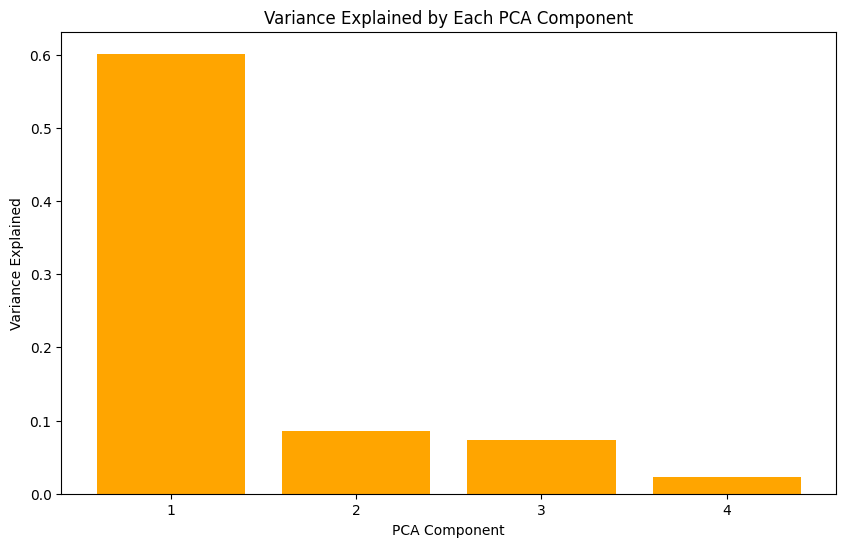

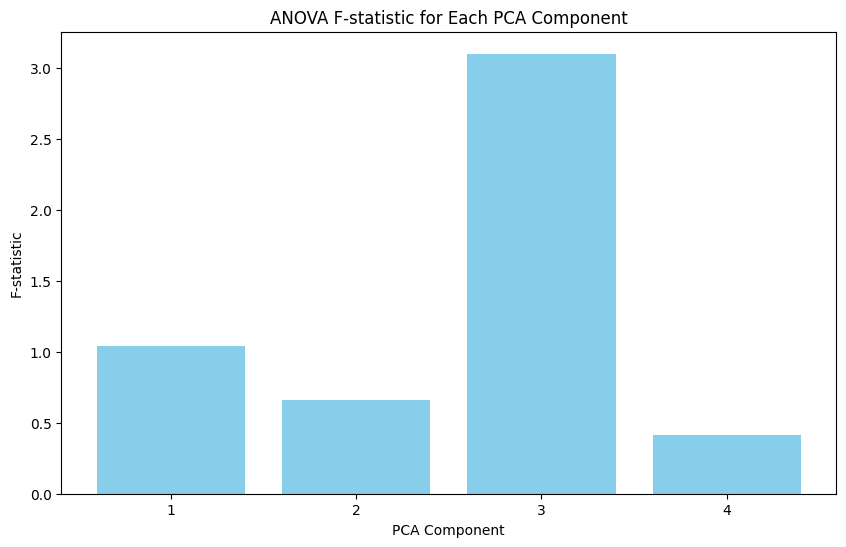

In [266]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

 # 100 samples, 5 features (replace with your data)
batch_labels = covariates_clinical_data_AD_NCI.braaksc.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(count_matrix_raw)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Create a DataFrame to store ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])

# Display ANOVA results
print(anova_results_df)

# Plotting Variance Explained by PCA Components
plt.figure(figsize=(10, 6))
plt.bar(range(1, pca.n_components + 1), pca.explained_variance_ratio_, color='orange')
plt.xlabel('PCA Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by Each PCA Component')
plt.xticks(range(1, pca.n_components + 1))
plt.show()

# Plotting ANOVA Results (F-statistics)
plt.figure(figsize=(10, 6))
plt.bar(anova_results_df['PCA Component'], anova_results_df['F-statistic'], color='skyblue')
plt.xlabel('PCA Component')
plt.ylabel('F-statistic')
plt.title('ANOVA F-statistic for Each PCA Component')
plt.xticks(anova_results_df['PCA Component'])
plt.show()


   PCA Component  F-statistic   P-value
0              1     1.038277  0.402019
1              2     0.662261  0.680226
2              3     3.100949  0.006477
3              4     0.417120  0.867020


/tmp/ipykernel_62296/3962680026.py:21: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



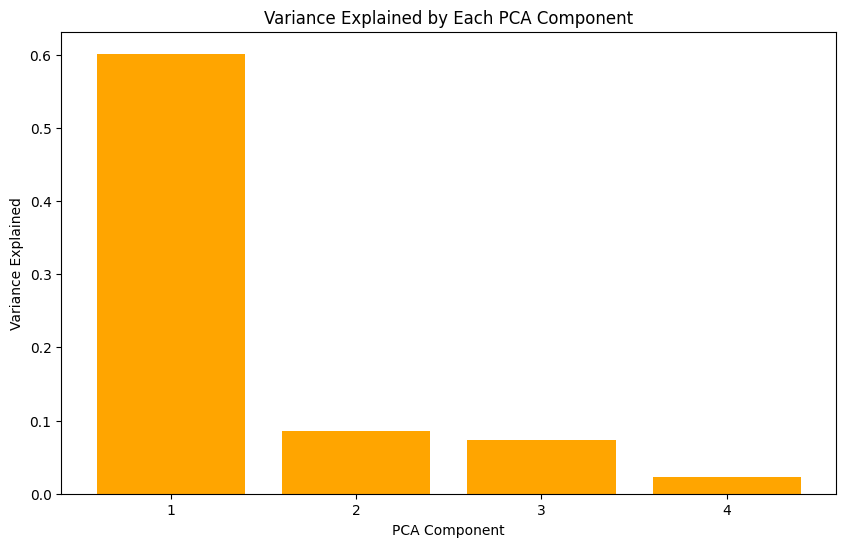

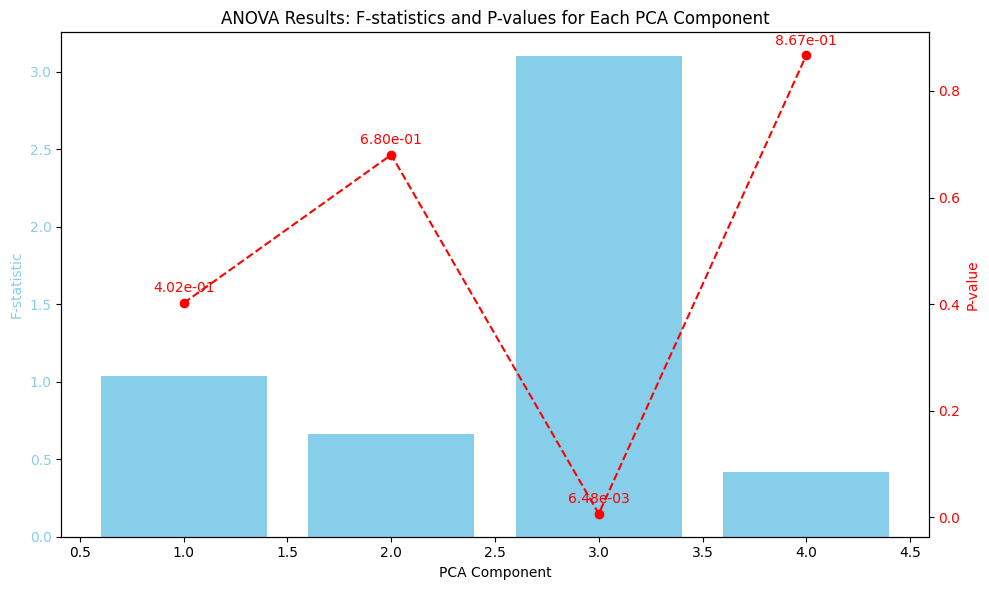

In [267]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels = covariates_clinical_data_AD_NCI.braaksc.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(count_matrix_raw)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Create a DataFrame to store ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])

# Display ANOVA results
print(anova_results_df)

# Plotting Variance Explained by PCA Components
plt.figure(figsize=(10, 6))
plt.bar(range(1, pca.n_components + 1), pca.explained_variance_ratio_, color='orange')
plt.xlabel('PCA Component')
plt.ylabel('Variance Explained')
plt.title('Variance Explained by Each PCA Component')
plt.xticks(range(1, pca.n_components + 1))
plt.show()

# Plotting ANOVA Results (F-statistics and P-values)
fig, ax1 = plt.subplots(figsize=(10, 6))

# F-statistics bar plot
ax1.bar(anova_results_df['PCA Component'], anova_results_df['F-statistic'], color='skyblue', label='F-statistic')
ax1.set_xlabel('PCA Component')
ax1.set_ylabel('F-statistic', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Create another y-axis for P-values
ax2 = ax1.twinx()
ax2.plot(anova_results_df['PCA Component'], anova_results_df['P-value'], color='red', marker='o', label='P-value', linestyle='--')
ax2.set_ylabel('P-value', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add P-values as text above the bars
for i, p_value in enumerate(anova_results_df['P-value']):
    ax2.text(anova_results_df['PCA Component'][i], p_value + 0.02, f'{p_value:.2e}', ha='center', color='red')

# Title and legends
plt.title('ANOVA Results: F-statistics and P-values for Each PCA Component')
fig.tight_layout()  # Adjust layout to make space for labels
plt.show()


#### remove batch 7 and see

In [268]:
covariates_clinical_data_AD_NCI_without_batch_7 = covariates_clinical_data_AD_NCI[covariates_clinical_data_AD_NCI.Batch!=7.0]
covariates_clinical_data_AD_NCI_without_batch_7

,Batch,educ,cogdx,race,pmi,age_at_visit_max,ceradsc,braaksc,msex,Category
specimenID,,,,,,,,,,
23_120411,6,18.0,4.0,1.0,6.416667,90,1.0,4.0,0.0,AD with Plaques
591_120522,2,12.0,4.0,1.0,5.200000,90,1.0,4.0,0.0,AD with Plaques
691_120605,5,14.0,1.0,1.0,4.833333,90,4.0,3.0,0.0,NCI with No Plaques
588_120522,1,18.0,1.0,1.0,4.400000,90,4.0,4.0,0.0,NCI with No Plaques
604_120523,2,20.0,4.0,1.0,17.833333,90,1.0,5.0,0.0,AD with Plaques
...,...,...,...,...,...,...,...,...,...,...
677_120604,4,23.0,1.0,1.0,18.666667,71.720739219712527,4.0,3.0,0.0,NCI with No Plaques
142_120419,6,23.0,1.0,1.0,7.000000,71.60301163586584,4.0,2.0,1.0,NCI with No Plaques
120_120418,5,26.0,1.0,1.0,4.083333,71.482546201232026,4.0,1.0,1.0,NCI with No Plaques


In [269]:
count_matrix_raw_without_batch_7 = count_matrix_raw.loc[covariates_clinical_data_AD_NCI_without_batch_7.index,]

   PCA Component  F-statistic       P-value
0              1   111.906713  1.045398e-58
1              2    10.613819  5.837951e-11
2              3     4.870694  5.222684e-05
3              4    27.800491  7.412380e-25
[0.65508388 0.0860046  0.03645897 0.02128441]


/tmp/ipykernel_62296/2572723600.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



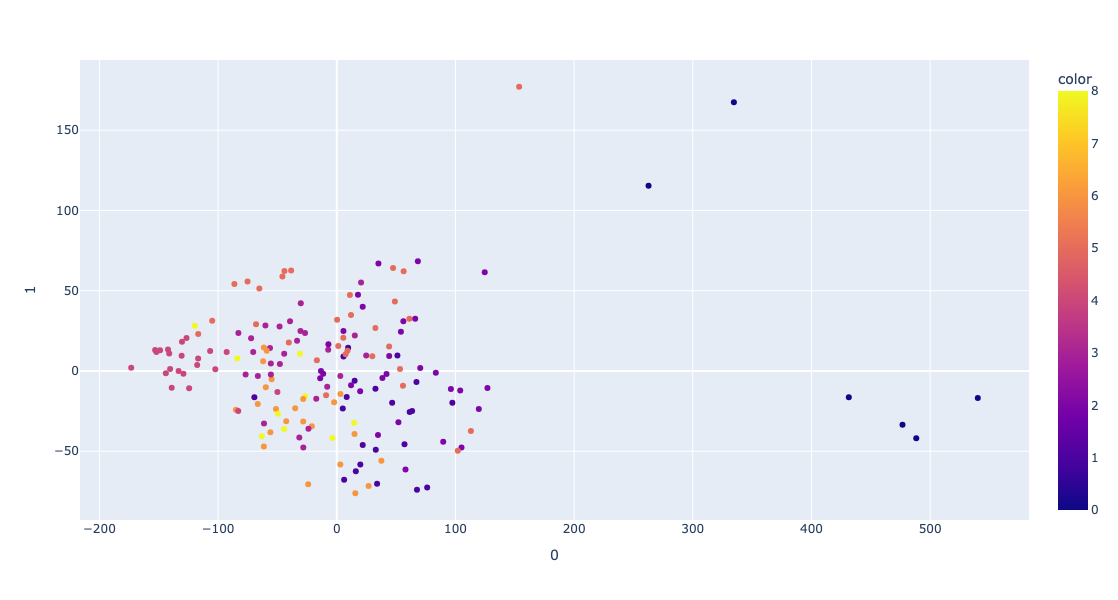

In [270]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels =  covariates_clinical_data_AD_NCI_without_batch_7.Batch.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(count_matrix_raw_without_batch_7)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)
print(pca.explained_variance_ratio_)
import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)

# Fit the PCA and transform the data
X_scaled = scaler.fit_transform(count_matrix_raw_without_batch_7)
components = pca.fit_transform(X_scaled)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=covariates_clinical_data_AD_NCI_without_batch_7.Batch.tolist() )

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()

In [271]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels =  covariates_clinical_data_AD_NCI_without_batch_7.cogdx.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(count_matrix_raw_without_batch_7)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)
print(pca.explained_variance_ratio_)
import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)

# Fit the PCA and transform the data
X_scaled = scaler.fit_transform(count_matrix_raw_without_batch_7)
components = pca.fit_transform(X_scaled)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=covariates_clinical_data_AD_NCI_without_batch_7.Batch.tolist() )

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()

   PCA Component  F-statistic   P-value
0              1     5.031246  0.026201
1              2    12.946090  0.000421
2              3     0.431210  0.512294
3              4     2.146508  0.144763
[0.65508388 0.0860046  0.03645897 0.02128441]


/tmp/ipykernel_62296/113341756.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



In [272]:
count_matrix_raw_without_batch_7

,ENSG00000115282,ENSG00000239305,ENSG00000174827,ENSG00000256422,ENSG00000066933,ENSG00000108379,ENSG00000174437,ENSG00000078304,ENSG00000101443,ENSG00000204217,...,ENSG00000165591,ENSG00000113532,ENSG00000151892,ENSG00000102100,ENSG00000279765,ENSG00000103657,ENSG00000011105,ENSG00000129515,ENSG00000214174,ENSG00000235944
specimenID,,,,,,,,,,,,,,,,,,,,,
23_120411,305,451,28,36,1313,344,7045,1718,140,1371,...,26,82,524,274,14,2669,618,472,491,270
591_120522,323,709,35,45,2103,414,8685,2581,199,2176,...,50,129,499,367,40,3430,762,712,702,372
691_120605,381,638,33,49,2041,362,7019,2565,187,1894,...,58,112,566,302,27,3110,741,699,751,262
588_120522,280,624,31,38,1760,324,8138,2377,124,1873,...,48,104,708,296,35,3585,655,523,606,260
604_120523,331,816,39,61,2207,811,10917,3497,208,2795,...,55,178,690,444,59,4826,749,822,879,458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,165,275,16,13,768,87,3075,1159,45,914,...,16,53,438,126,32,1204,336,392,259,125
142_120419,186,412,23,15,1279,173,6775,1962,57,1536,...,18,81,229,288,18,2590,331,431,536,177
120_120418,267,444,44,22,1429,100,3030,1472,87,1076,...,29,66,464,186,58,1849,558,655,498,294


In [273]:
covariates_clinical_data_AD_NCI_without_batch_7

,Batch,educ,cogdx,race,pmi,age_at_visit_max,ceradsc,braaksc,msex,Category
specimenID,,,,,,,,,,
23_120411,6,18.0,4.0,1.0,6.416667,90,1.0,4.0,0.0,AD with Plaques
591_120522,2,12.0,4.0,1.0,5.200000,90,1.0,4.0,0.0,AD with Plaques
691_120605,5,14.0,1.0,1.0,4.833333,90,4.0,3.0,0.0,NCI with No Plaques
588_120522,1,18.0,1.0,1.0,4.400000,90,4.0,4.0,0.0,NCI with No Plaques
604_120523,2,20.0,4.0,1.0,17.833333,90,1.0,5.0,0.0,AD with Plaques
...,...,...,...,...,...,...,...,...,...,...
677_120604,4,23.0,1.0,1.0,18.666667,71.720739219712527,4.0,3.0,0.0,NCI with No Plaques
142_120419,6,23.0,1.0,1.0,7.000000,71.60301163586584,4.0,2.0,1.0,NCI with No Plaques
120_120418,5,26.0,1.0,1.0,4.083333,71.482546201232026,4.0,1.0,1.0,NCI with No Plaques


In [274]:
!mkdir data_preprocessed/temp_count_matrix_covariates_removal

mkdir: cannot create directory ‘data_preprocessed/temp_count_matrix_covariates_removal’: File exists


In [275]:
count_matrix_raw_without_batch_7.to_csv('data_preprocessed/temp_count_matrix_covariates_removal/count_matrix_raw_without_batch_7.csv')

In [276]:
covariates_clinical_data_AD_NCI_without_batch_7.to_csv('data_preprocessed/temp_count_matrix_covariates_removal/covariates_clinical_data_AD_NCI_without_batch_7.csv')

In [277]:
covariates_clinical_data_AD_NCI_without_batch_7_and_0 = covariates_clinical_data_AD_NCI_without_batch_7[covariates_clinical_data_AD_NCI_without_batch_7.Batch!=0.0]
covariates_clinical_data_AD_NCI_without_batch_7_and_0

,Batch,educ,cogdx,race,pmi,age_at_visit_max,ceradsc,braaksc,msex,Category
specimenID,,,,,,,,,,
23_120411,6,18.0,4.0,1.0,6.416667,90,1.0,4.0,0.0,AD with Plaques
591_120522,2,12.0,4.0,1.0,5.200000,90,1.0,4.0,0.0,AD with Plaques
691_120605,5,14.0,1.0,1.0,4.833333,90,4.0,3.0,0.0,NCI with No Plaques
588_120522,1,18.0,1.0,1.0,4.400000,90,4.0,4.0,0.0,NCI with No Plaques
604_120523,2,20.0,4.0,1.0,17.833333,90,1.0,5.0,0.0,AD with Plaques
...,...,...,...,...,...,...,...,...,...,...
677_120604,4,23.0,1.0,1.0,18.666667,71.720739219712527,4.0,3.0,0.0,NCI with No Plaques
142_120419,6,23.0,1.0,1.0,7.000000,71.60301163586584,4.0,2.0,1.0,NCI with No Plaques
120_120418,5,26.0,1.0,1.0,4.083333,71.482546201232026,4.0,1.0,1.0,NCI with No Plaques


In [278]:
count_matrix_raw_without_batch_7_and_0 = count_matrix_raw_without_batch_7.loc[covariates_clinical_data_AD_NCI_without_batch_7_and_0.index,]
count_matrix_raw_without_batch_7_and_0 

,ENSG00000115282,ENSG00000239305,ENSG00000174827,ENSG00000256422,ENSG00000066933,ENSG00000108379,ENSG00000174437,ENSG00000078304,ENSG00000101443,ENSG00000204217,...,ENSG00000165591,ENSG00000113532,ENSG00000151892,ENSG00000102100,ENSG00000279765,ENSG00000103657,ENSG00000011105,ENSG00000129515,ENSG00000214174,ENSG00000235944
specimenID,,,,,,,,,,,,,,,,,,,,,
23_120411,305,451,28,36,1313,344,7045,1718,140,1371,...,26,82,524,274,14,2669,618,472,491,270
591_120522,323,709,35,45,2103,414,8685,2581,199,2176,...,50,129,499,367,40,3430,762,712,702,372
691_120605,381,638,33,49,2041,362,7019,2565,187,1894,...,58,112,566,302,27,3110,741,699,751,262
588_120522,280,624,31,38,1760,324,8138,2377,124,1873,...,48,104,708,296,35,3585,655,523,606,260
604_120523,331,816,39,61,2207,811,10917,3497,208,2795,...,55,178,690,444,59,4826,749,822,879,458
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,165,275,16,13,768,87,3075,1159,45,914,...,16,53,438,126,32,1204,336,392,259,125
142_120419,186,412,23,15,1279,173,6775,1962,57,1536,...,18,81,229,288,18,2590,331,431,536,177
120_120418,267,444,44,22,1429,100,3030,1472,87,1076,...,29,66,464,186,58,1849,558,655,498,294


In [279]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels =  covariates_clinical_data_AD_NCI_without_batch_7_and_0.Batch.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(count_matrix_raw_without_batch_7_and_0)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)
print(pca.explained_variance_ratio_)
import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)

# Fit the PCA and transform the data
X_scaled = scaler.fit_transform(count_matrix_raw_without_batch_7_and_0)
components = pca.fit_transform(X_scaled)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=covariates_clinical_data_AD_NCI_without_batch_7_and_0.Batch.tolist() )

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()

   PCA Component  F-statistic       P-value
0              1    45.216118  7.961873e-32
1              2    15.141059  1.221935e-13
2              3     9.109223  1.502152e-08
3              4    20.628491  9.772330e-18
[0.5173153  0.1139694  0.05529865 0.03444528]


/tmp/ipykernel_62296/523318854.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



In [280]:
set(batch_labels)

{1, 2, 3, 4, 5, 6, 8}

In [281]:
count_matrix_after_iteration_without_batch_7_1_batch = pd.read_csv('data_preprocessed/temp_count_matrix_covariates_removal/count_matrix_after_iteration_without_batch_7_1_batch.csv', index_col = 0)
count_matrix_after_iteration_without_batch_7_1_batch


,23_120411,591_120522,691_120605,588_120522,604_120523,545_120516,364_120502,705_120605,711_120531,602_120523,...,628_120524,587_120522,168_120423,283_120430,721_120531,677_120604,142_120419,120_120418,483_120515,174_120424
ENSG00000101901,434,497,530,367,575,227,381,278,348,615,...,209,301,497,314,298,345,280,404,547,421
ENSG00000174839,392,392,484,428,485,287,396,333,327,534,...,246,289,342,252,231,315,260,417,324,448
ENSG00000151466,216,268,252,233,410,206,259,199,224,290,...,138,181,270,217,143,186,167,259,206,278
ENSG00000168288,290,432,508,326,600,236,330,355,387,579,...,215,200,420,313,242,319,265,282,486,378
ENSG00000112343,130,157,200,130,146,121,106,103,129,187,...,80,79,74,54,122,141,125,198,127,357
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000120457,49,28,100,17,68,63,24,39,26,79,...,11,14,39,11,21,14,48,27,48,34
ENSG00000100528,662,906,1186,710,1104,438,714,664,855,1392,...,623,671,924,679,429,677,552,675,1153,798
ENSG00000116205,411,508,504,406,560,247,425,361,458,528,...,257,477,349,308,348,338,379,507,521,552
ENSG00000100603,530,648,724,587,918,428,556,545,509,818,...,398,393,643,527,439,451,392,626,627,630


In [282]:
covariates_clinical_data_AD_NCI_without_batch_7

,Batch,educ,cogdx,race,pmi,age_at_visit_max,ceradsc,braaksc,msex,Category
specimenID,,,,,,,,,,
23_120411,6,18.0,4.0,1.0,6.416667,90,1.0,4.0,0.0,AD with Plaques
591_120522,2,12.0,4.0,1.0,5.200000,90,1.0,4.0,0.0,AD with Plaques
691_120605,5,14.0,1.0,1.0,4.833333,90,4.0,3.0,0.0,NCI with No Plaques
588_120522,1,18.0,1.0,1.0,4.400000,90,4.0,4.0,0.0,NCI with No Plaques
604_120523,2,20.0,4.0,1.0,17.833333,90,1.0,5.0,0.0,AD with Plaques
...,...,...,...,...,...,...,...,...,...,...
677_120604,4,23.0,1.0,1.0,18.666667,71.720739219712527,4.0,3.0,0.0,NCI with No Plaques
142_120419,6,23.0,1.0,1.0,7.000000,71.60301163586584,4.0,2.0,1.0,NCI with No Plaques
120_120418,5,26.0,1.0,1.0,4.083333,71.482546201232026,4.0,1.0,1.0,NCI with No Plaques


In [283]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels =  covariates_clinical_data_AD_NCI_without_batch_7.Batch.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(count_matrix_after_iteration_without_batch_7_1_batch.T)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)
print(pca.explained_variance_ratio_)
import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)

# Fit the PCA and transform the data
X_scaled = scaler.fit_transform(count_matrix_after_iteration_without_batch_7_1_batch.T)
components = pca.fit_transform(X_scaled)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=covariates_clinical_data_AD_NCI_without_batch_7.Batch.tolist() )

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()

   PCA Component  F-statistic       P-value
0              1    83.075615  2.542465e-50
1              2     1.281167  2.627006e-01
2              3     0.153819  9.932500e-01
3              4     0.183566  9.884516e-01
[0.65395087 0.08260589 0.03713096 0.02082191]


/tmp/ipykernel_62296/1083924538.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



In [284]:
covariates_clinical_data_AD_NCI_without_batch_7.Batch.value_counts()

Batch
5    31
2    29
3    28
6    23
1    22
4    22
8     9
0     6
Name: count, dtype: int64

In [285]:
covariates_clinical_data_AD_NCI_without_batch_7.Category.value_counts()

Category
AD with Plaques        97
NCI with No Plaques    73
Name: count, dtype: int64

In [286]:
count_matrix_after_iteration_without_batch_7_1_batch.T

,ENSG00000101901,ENSG00000174839,ENSG00000151466,ENSG00000168288,ENSG00000112343,ENSG00000172890,ENSG00000150991,ENSG00000100029,ENSG00000181894,ENSG00000206560,...,ENSG00000039560,ENSG00000223496,ENSG00000166681,ENSG00000078061,ENSG00000272143,ENSG00000120457,ENSG00000100528,ENSG00000116205,ENSG00000100603,ENSG00000114933
23_120411,434,392,216,290,130,755,3276,582,302,692,...,136,1598,5131,363,50,49,662,411,530,366
591_120522,497,392,268,432,157,844,6423,777,520,876,...,191,2719,7720,411,47,28,906,508,648,451
691_120605,530,484,252,508,200,1171,8300,947,525,1047,...,167,2728,9469,566,74,100,1186,504,724,470
588_120522,367,428,233,326,130,1129,6307,738,374,821,...,134,2097,4785,513,91,17,710,406,587,365
604_120523,575,485,410,600,146,1065,8918,1122,551,1289,...,223,3768,12588,525,67,68,1104,560,918,540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,345,315,186,319,141,638,4550,554,274,576,...,149,1529,4705,359,38,14,677,338,451,261
142_120419,280,260,167,265,125,601,4328,515,324,669,...,153,1104,5357,336,28,48,552,379,392,254
120_120418,404,417,259,282,198,1045,4818,833,359,830,...,206,2261,5185,399,50,27,675,507,626,408
483_120515,547,324,206,486,127,949,7626,971,591,994,...,144,3253,7818,382,37,48,1153,521,627,403


In [287]:
pca_df = pd.DataFrame(components, columns=['PC1', 'PC2'])
pca_df.index = count_matrix_after_iteration_without_batch_7_1_batch.T.index

In [288]:
# Set a threshold using the 1st and 99th percentiles for PC1 and PC2
lower_quantile = pca_df.quantile(0.01)
upper_quantile = pca_df.quantile(0.99)

# Identify outliers based on the quantile thresholds
outliers_quantile = ((pca_df < lower_quantile) | (pca_df > upper_quantile)).any(axis=1)

# Check outlier indices
print(f"Outlier indices based on quantile thresholds: {np.where(outliers_quantile)[0]}")


Outlier indices based on quantile thresholds: [ 26  56  73  90 117 133 136 148]


In [289]:
pca_df

,PC1,PC2
23_120411,-50.892592,0.647316
591_120522,16.441081,-10.581598
691_120605,61.044875,-12.547063
588_120522,-7.529054,23.665054
604_120523,104.227577,-42.181541
...,...,...
677_120604,-78.764750,-7.889946
142_120419,-78.568231,-14.061362
120_120418,-7.655985,31.886155
483_120515,34.096584,-49.626773


In [290]:
lower_quantile

PC1   -132.801639
PC2    -72.407173
Name: 0.01, dtype: float64

In [291]:
outliers = pca_df[outliers_quantile].index.tolist()

In [292]:
outliers

['186_120424',
 '398_120503',
 '405_120503',
 '383_120503',
 '560_120517',
 '79_120417',
 '150_120419',
 '929_131031']

In [293]:
final_covariates_data = covariates_clinical_data_AD_NCI_without_batch_7.reset_index()[ ~covariates_clinical_data_AD_NCI_without_batch_7.reset_index().specimenID.isin(outliers)]
final_covariates_data.set_index('specimenID', inplace = True)
final_covariates_data

,Batch,educ,cogdx,race,pmi,age_at_visit_max,ceradsc,braaksc,msex,Category
specimenID,,,,,,,,,,
23_120411,6,18.0,4.0,1.0,6.416667,90,1.0,4.0,0.0,AD with Plaques
591_120522,2,12.0,4.0,1.0,5.200000,90,1.0,4.0,0.0,AD with Plaques
691_120605,5,14.0,1.0,1.0,4.833333,90,4.0,3.0,0.0,NCI with No Plaques
588_120522,1,18.0,1.0,1.0,4.400000,90,4.0,4.0,0.0,NCI with No Plaques
604_120523,2,20.0,4.0,1.0,17.833333,90,1.0,5.0,0.0,AD with Plaques
...,...,...,...,...,...,...,...,...,...,...
677_120604,4,23.0,1.0,1.0,18.666667,71.720739219712527,4.0,3.0,0.0,NCI with No Plaques
142_120419,6,23.0,1.0,1.0,7.000000,71.60301163586584,4.0,2.0,1.0,NCI with No Plaques
120_120418,5,26.0,1.0,1.0,4.083333,71.482546201232026,4.0,1.0,1.0,NCI with No Plaques


In [294]:
final_count_matrix = count_matrix_after_iteration_without_batch_7_1_batch.T
final_count_matrix = final_count_matrix[final_count_matrix.index.isin(final_covariates_data.index)]
final_count_matrix

,ENSG00000101901,ENSG00000174839,ENSG00000151466,ENSG00000168288,ENSG00000112343,ENSG00000172890,ENSG00000150991,ENSG00000100029,ENSG00000181894,ENSG00000206560,...,ENSG00000039560,ENSG00000223496,ENSG00000166681,ENSG00000078061,ENSG00000272143,ENSG00000120457,ENSG00000100528,ENSG00000116205,ENSG00000100603,ENSG00000114933
23_120411,434,392,216,290,130,755,3276,582,302,692,...,136,1598,5131,363,50,49,662,411,530,366
591_120522,497,392,268,432,157,844,6423,777,520,876,...,191,2719,7720,411,47,28,906,508,648,451
691_120605,530,484,252,508,200,1171,8300,947,525,1047,...,167,2728,9469,566,74,100,1186,504,724,470
588_120522,367,428,233,326,130,1129,6307,738,374,821,...,134,2097,4785,513,91,17,710,406,587,365
604_120523,575,485,410,600,146,1065,8918,1122,551,1289,...,223,3768,12588,525,67,68,1104,560,918,540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,345,315,186,319,141,638,4550,554,274,576,...,149,1529,4705,359,38,14,677,338,451,261
142_120419,280,260,167,265,125,601,4328,515,324,669,...,153,1104,5357,336,28,48,552,379,392,254
120_120418,404,417,259,282,198,1045,4818,833,359,830,...,206,2261,5185,399,50,27,675,507,626,408
483_120515,547,324,206,486,127,949,7626,971,591,994,...,144,3253,7818,382,37,48,1153,521,627,403


/tmp/ipykernel_62296/2231068478.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



   PCA Component  F-statistic       P-value
0              1    50.515960  8.825277e-37
1              2     1.751869  1.009312e-01
2              3     0.473678  8.525376e-01
3              4     0.160021  9.923657e-01
[0.57794181 0.08309468 0.04774772 0.02959866]


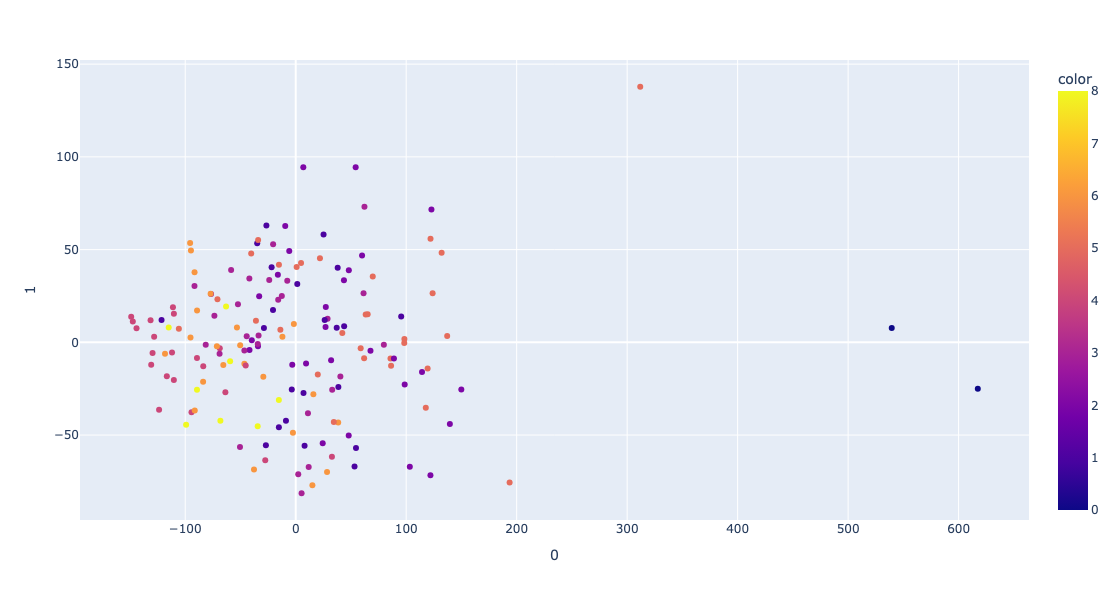

In [295]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels = final_covariates_data.Batch.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(final_count_matrix)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)
print(pca.explained_variance_ratio_)
import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)

# Fit the PCA and transform the data
X_scaled = scaler.fit_transform(final_count_matrix)
components = pca.fit_transform(X_scaled)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=final_covariates_data.Batch.tolist() )

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()

In [296]:
final_covariates_data.Category.value_counts()

Category
AD with Plaques        92
NCI with No Plaques    70
Name: count, dtype: int64

In [297]:
pca_df = pd.DataFrame(components, columns=['PC1', 'PC2'])
pca_df.index = final_count_matrix.index

In [298]:
# Set a threshold using the 1st and 99th percentiles for PC1 and PC2
lower_quantile = pca_df.quantile(0.001)
upper_quantile = pca_df.quantile(0.999)

# Identify outliers based on the quantile thresholds
outliers_quantile = ((pca_df < lower_quantile) | (pca_df > upper_quantile)).any(axis=1)

# Check outlier indices
print(f"Outlier indices based on quantile thresholds: {np.where(outliers_quantile)[0]}")


Outlier indices based on quantile thresholds: [ 33  41  99 119]


In [299]:
outliers = pca_df[outliers_quantile].index.tolist()
pca_df.index = final_count_matrix.index
outliers

['486_120515', '369_120502', '583_120522', '145_120419']

In [300]:
final_covariates_data = final_covariates_data .reset_index()[ ~final_covariates_data.reset_index().specimenID.isin(outliers)]
final_covariates_data.set_index('specimenID', inplace = True)
final_covariates_data

,Batch,educ,cogdx,race,pmi,age_at_visit_max,ceradsc,braaksc,msex,Category
specimenID,,,,,,,,,,
23_120411,6,18.0,4.0,1.0,6.416667,90,1.0,4.0,0.0,AD with Plaques
591_120522,2,12.0,4.0,1.0,5.200000,90,1.0,4.0,0.0,AD with Plaques
691_120605,5,14.0,1.0,1.0,4.833333,90,4.0,3.0,0.0,NCI with No Plaques
588_120522,1,18.0,1.0,1.0,4.400000,90,4.0,4.0,0.0,NCI with No Plaques
604_120523,2,20.0,4.0,1.0,17.833333,90,1.0,5.0,0.0,AD with Plaques
...,...,...,...,...,...,...,...,...,...,...
677_120604,4,23.0,1.0,1.0,18.666667,71.720739219712527,4.0,3.0,0.0,NCI with No Plaques
142_120419,6,23.0,1.0,1.0,7.000000,71.60301163586584,4.0,2.0,1.0,NCI with No Plaques
120_120418,5,26.0,1.0,1.0,4.083333,71.482546201232026,4.0,1.0,1.0,NCI with No Plaques


In [301]:
final_count_matrix = final_count_matrix
final_count_matrix = final_count_matrix[final_count_matrix.index.isin(final_covariates_data.index)]
final_count_matrix

,ENSG00000101901,ENSG00000174839,ENSG00000151466,ENSG00000168288,ENSG00000112343,ENSG00000172890,ENSG00000150991,ENSG00000100029,ENSG00000181894,ENSG00000206560,...,ENSG00000039560,ENSG00000223496,ENSG00000166681,ENSG00000078061,ENSG00000272143,ENSG00000120457,ENSG00000100528,ENSG00000116205,ENSG00000100603,ENSG00000114933
23_120411,434,392,216,290,130,755,3276,582,302,692,...,136,1598,5131,363,50,49,662,411,530,366
591_120522,497,392,268,432,157,844,6423,777,520,876,...,191,2719,7720,411,47,28,906,508,648,451
691_120605,530,484,252,508,200,1171,8300,947,525,1047,...,167,2728,9469,566,74,100,1186,504,724,470
588_120522,367,428,233,326,130,1129,6307,738,374,821,...,134,2097,4785,513,91,17,710,406,587,365
604_120523,575,485,410,600,146,1065,8918,1122,551,1289,...,223,3768,12588,525,67,68,1104,560,918,540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,345,315,186,319,141,638,4550,554,274,576,...,149,1529,4705,359,38,14,677,338,451,261
142_120419,280,260,167,265,125,601,4328,515,324,669,...,153,1104,5357,336,28,48,552,379,392,254
120_120418,404,417,259,282,198,1045,4818,833,359,830,...,206,2261,5185,399,50,27,675,507,626,408
483_120515,547,324,206,486,127,949,7626,971,591,994,...,144,3253,7818,382,37,48,1153,521,627,403


   PCA Component  F-statistic       P-value
0              1    35.018868  1.357234e-28
1              2     1.981116  6.119845e-02
2              3     0.838665  5.569107e-01
3              4     0.362261  9.228000e-01
[0.51568036 0.09169159 0.05196451 0.03605626]


/tmp/ipykernel_62296/2231068478.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



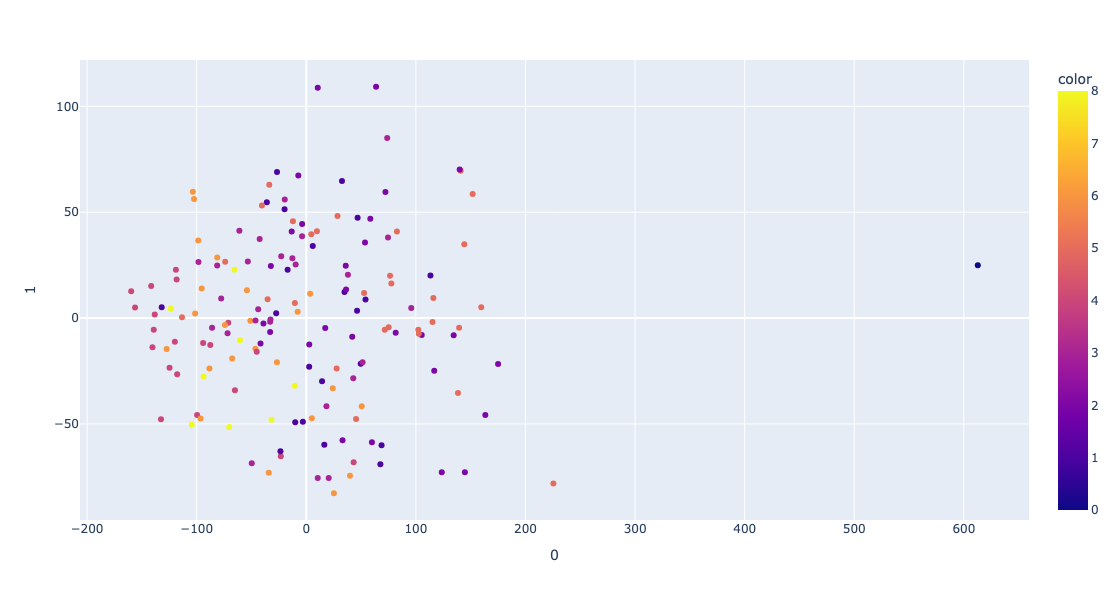

In [302]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels = final_covariates_data.Batch.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(final_count_matrix)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)
print(pca.explained_variance_ratio_)
import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)

# Fit the PCA and transform the data
X_scaled = scaler.fit_transform(final_count_matrix)
components = pca.fit_transform(X_scaled)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=final_covariates_data.Batch.tolist() )

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()

In [303]:
pca_df = pd.DataFrame(components, columns=['PC1', 'PC2'])
pca_df.index = final_count_matrix.index

In [304]:
# Set a threshold using the 1st and 99th percentiles for PC1 and PC2
lower_quantile = pca_df.quantile(0.001)
upper_quantile = pca_df.quantile(0.999)

# Identify outliers based on the quantile thresholds
outliers_quantile = ((pca_df < lower_quantile) | (pca_df > upper_quantile)).any(axis=1)

# Check outlier indices
print(f"Outlier indices based on quantile thresholds: {np.where(outliers_quantile)[0]}")


Outlier indices based on quantile thresholds: [ 44  65 127 150]


In [305]:
outliers = pca_df[outliers_quantile].index.tolist()
pca_df.index = final_count_matrix.index
outliers

['624_120524', '254_120426', '525_120515', '168_120423']

In [306]:
final_covariates_data = final_covariates_data .reset_index()[ ~final_covariates_data.reset_index().specimenID.isin(outliers)]
final_covariates_data.set_index('specimenID', inplace = True)
final_covariates_data

,Batch,educ,cogdx,race,pmi,age_at_visit_max,ceradsc,braaksc,msex,Category
specimenID,,,,,,,,,,
23_120411,6,18.0,4.0,1.0,6.416667,90,1.0,4.0,0.0,AD with Plaques
591_120522,2,12.0,4.0,1.0,5.200000,90,1.0,4.0,0.0,AD with Plaques
691_120605,5,14.0,1.0,1.0,4.833333,90,4.0,3.0,0.0,NCI with No Plaques
588_120522,1,18.0,1.0,1.0,4.400000,90,4.0,4.0,0.0,NCI with No Plaques
604_120523,2,20.0,4.0,1.0,17.833333,90,1.0,5.0,0.0,AD with Plaques
...,...,...,...,...,...,...,...,...,...,...
677_120604,4,23.0,1.0,1.0,18.666667,71.720739219712527,4.0,3.0,0.0,NCI with No Plaques
142_120419,6,23.0,1.0,1.0,7.000000,71.60301163586584,4.0,2.0,1.0,NCI with No Plaques
120_120418,5,26.0,1.0,1.0,4.083333,71.482546201232026,4.0,1.0,1.0,NCI with No Plaques


In [307]:
final_count_matrix = final_count_matrix
final_count_matrix = final_count_matrix[final_count_matrix.index.isin(final_covariates_data.index)]
final_count_matrix

,ENSG00000101901,ENSG00000174839,ENSG00000151466,ENSG00000168288,ENSG00000112343,ENSG00000172890,ENSG00000150991,ENSG00000100029,ENSG00000181894,ENSG00000206560,...,ENSG00000039560,ENSG00000223496,ENSG00000166681,ENSG00000078061,ENSG00000272143,ENSG00000120457,ENSG00000100528,ENSG00000116205,ENSG00000100603,ENSG00000114933
23_120411,434,392,216,290,130,755,3276,582,302,692,...,136,1598,5131,363,50,49,662,411,530,366
591_120522,497,392,268,432,157,844,6423,777,520,876,...,191,2719,7720,411,47,28,906,508,648,451
691_120605,530,484,252,508,200,1171,8300,947,525,1047,...,167,2728,9469,566,74,100,1186,504,724,470
588_120522,367,428,233,326,130,1129,6307,738,374,821,...,134,2097,4785,513,91,17,710,406,587,365
604_120523,575,485,410,600,146,1065,8918,1122,551,1289,...,223,3768,12588,525,67,68,1104,560,918,540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,345,315,186,319,141,638,4550,554,274,576,...,149,1529,4705,359,38,14,677,338,451,261
142_120419,280,260,167,265,125,601,4328,515,324,669,...,153,1104,5357,336,28,48,552,379,392,254
120_120418,404,417,259,282,198,1045,4818,833,359,830,...,206,2261,5185,399,50,27,675,507,626,408
483_120515,547,324,206,486,127,949,7626,971,591,994,...,144,3253,7818,382,37,48,1153,521,627,403


/tmp/ipykernel_62296/2231068478.py:20: FutureWarning:

factorize with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.



   PCA Component  F-statistic       P-value
0              1    21.552375  4.544554e-18
1              2     2.638824  1.847796e-02
2              3     1.147309  3.379775e-01
3              4     0.159511  9.868369e-01
[0.46019229 0.10023323 0.06050765 0.04189159]


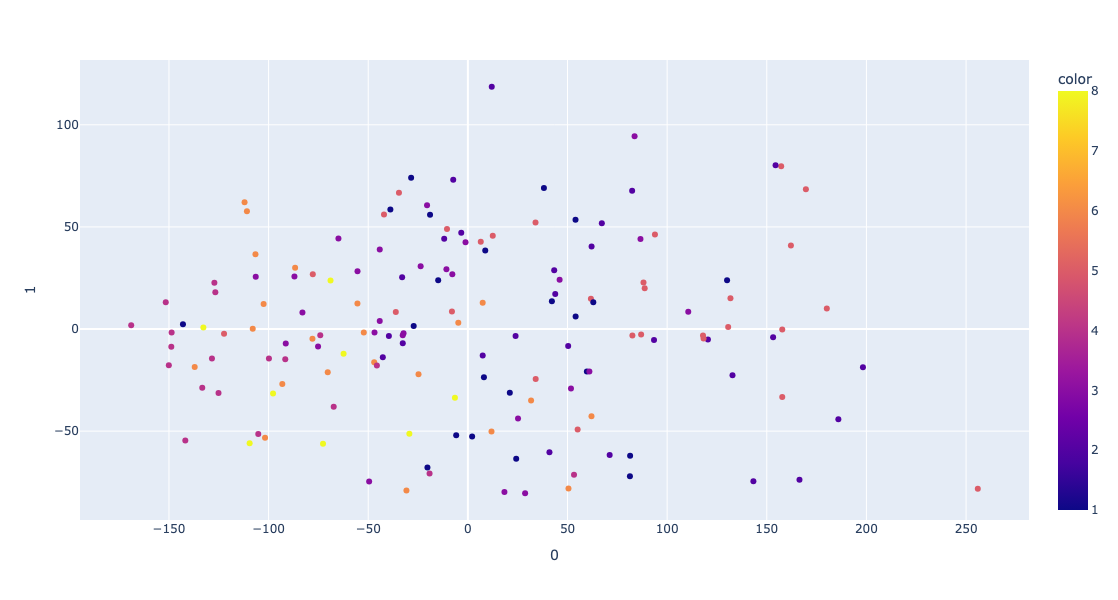

In [308]:
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.stats import f_oneway

# Example Data (Replace with your dataset)
X = np.random.randn(100, 5)  # 100 samples, 5 features (replace with your data)
batch_labels = final_covariates_data.Batch.tolist()  # Categorical labels with more than two categories

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(final_count_matrix)

# Perform PCA
pca = PCA(n_components=4)  # You can change the number of components
pca_components = pca.fit_transform(X_scaled)

# Convert batch labels to numeric values for ANOVA
batch_numeric = pd.factorize(batch_labels)[0]

# Perform ANOVA for each PCA component
anova_results = []
for i in range(pca_components.shape[1]):
    groups = [pca_components[batch_numeric == j, i] for j in np.unique(batch_numeric)]
    f_stat, p_value = f_oneway(*groups)
    anova_results.append((i + 1, f_stat, p_value))

# Display ANOVA results
anova_results_df = pd.DataFrame(anova_results, columns=["PCA Component", "F-statistic", "P-value"])
print(anova_results_df)
print(pca.explained_variance_ratio_)
import plotly.express as px
from sklearn.decomposition import PCA

# Assuming count_matrix_raw is the data matrix you are using for PCA
# And m is a categorical variable you want to use for coloring the scatter plot
pca = PCA(n_components=2)

# Fit the PCA and transform the data
X_scaled = scaler.fit_transform(final_count_matrix)
components = pca.fit_transform(X_scaled)

# Create the scatter plot with discrete coloring for the categories in m
fig = px.scatter(components, x=0, y=1, color=final_covariates_data.Batch.tolist() )

# Set custom width and height
fig.update_layout(
    width=800,  # Adjust width as needed
    height=600  # Adjust height as needed
)

# Save the plot to an HTML file
#fig.write_html("pca_batch(filtered_ad_non_ad_mrn_batch_corrected).html")

# Show the plot
fig.show()

In [309]:
final_covariates_data.Category.value_counts()

Category
AD with Plaques        87
NCI with No Plaques    67
Name: count, dtype: int64

In [310]:
final_count_matrix

,ENSG00000101901,ENSG00000174839,ENSG00000151466,ENSG00000168288,ENSG00000112343,ENSG00000172890,ENSG00000150991,ENSG00000100029,ENSG00000181894,ENSG00000206560,...,ENSG00000039560,ENSG00000223496,ENSG00000166681,ENSG00000078061,ENSG00000272143,ENSG00000120457,ENSG00000100528,ENSG00000116205,ENSG00000100603,ENSG00000114933
23_120411,434,392,216,290,130,755,3276,582,302,692,...,136,1598,5131,363,50,49,662,411,530,366
591_120522,497,392,268,432,157,844,6423,777,520,876,...,191,2719,7720,411,47,28,906,508,648,451
691_120605,530,484,252,508,200,1171,8300,947,525,1047,...,167,2728,9469,566,74,100,1186,504,724,470
588_120522,367,428,233,326,130,1129,6307,738,374,821,...,134,2097,4785,513,91,17,710,406,587,365
604_120523,575,485,410,600,146,1065,8918,1122,551,1289,...,223,3768,12588,525,67,68,1104,560,918,540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,345,315,186,319,141,638,4550,554,274,576,...,149,1529,4705,359,38,14,677,338,451,261
142_120419,280,260,167,265,125,601,4328,515,324,669,...,153,1104,5357,336,28,48,552,379,392,254
120_120418,404,417,259,282,198,1045,4818,833,359,830,...,206,2261,5185,399,50,27,675,507,626,408
483_120515,547,324,206,486,127,949,7626,971,591,994,...,144,3253,7818,382,37,48,1153,521,627,403


In [311]:
def return_AD_label(x):
    if x == "AD with Plaques":
        return 1
    elif x == "NCI with No Plaques":
        return 0
    else:
        return np.nan

In [312]:
final_covariates_data['Label'] = final_covariates_data.Category.apply(return_AD_label)
final_covariates_data['Label'] .value_counts()

Label
1    87
0    67
Name: count, dtype: int64

In [313]:
final_covariates_data

,Batch,educ,cogdx,race,pmi,age_at_visit_max,ceradsc,braaksc,msex,Category,Label
specimenID,,,,,,,,,,,
23_120411,6,18.0,4.0,1.0,6.416667,90,1.0,4.0,0.0,AD with Plaques,1
591_120522,2,12.0,4.0,1.0,5.200000,90,1.0,4.0,0.0,AD with Plaques,1
691_120605,5,14.0,1.0,1.0,4.833333,90,4.0,3.0,0.0,NCI with No Plaques,0
588_120522,1,18.0,1.0,1.0,4.400000,90,4.0,4.0,0.0,NCI with No Plaques,0
604_120523,2,20.0,4.0,1.0,17.833333,90,1.0,5.0,0.0,AD with Plaques,1
...,...,...,...,...,...,...,...,...,...,...,...
677_120604,4,23.0,1.0,1.0,18.666667,71.720739219712527,4.0,3.0,0.0,NCI with No Plaques,0
142_120419,6,23.0,1.0,1.0,7.000000,71.60301163586584,4.0,2.0,1.0,NCI with No Plaques,0
120_120418,5,26.0,1.0,1.0,4.083333,71.482546201232026,4.0,1.0,1.0,NCI with No Plaques,0


In [314]:
final_count_matrix

,ENSG00000101901,ENSG00000174839,ENSG00000151466,ENSG00000168288,ENSG00000112343,ENSG00000172890,ENSG00000150991,ENSG00000100029,ENSG00000181894,ENSG00000206560,...,ENSG00000039560,ENSG00000223496,ENSG00000166681,ENSG00000078061,ENSG00000272143,ENSG00000120457,ENSG00000100528,ENSG00000116205,ENSG00000100603,ENSG00000114933
23_120411,434,392,216,290,130,755,3276,582,302,692,...,136,1598,5131,363,50,49,662,411,530,366
591_120522,497,392,268,432,157,844,6423,777,520,876,...,191,2719,7720,411,47,28,906,508,648,451
691_120605,530,484,252,508,200,1171,8300,947,525,1047,...,167,2728,9469,566,74,100,1186,504,724,470
588_120522,367,428,233,326,130,1129,6307,738,374,821,...,134,2097,4785,513,91,17,710,406,587,365
604_120523,575,485,410,600,146,1065,8918,1122,551,1289,...,223,3768,12588,525,67,68,1104,560,918,540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,345,315,186,319,141,638,4550,554,274,576,...,149,1529,4705,359,38,14,677,338,451,261
142_120419,280,260,167,265,125,601,4328,515,324,669,...,153,1104,5357,336,28,48,552,379,392,254
120_120418,404,417,259,282,198,1045,4818,833,359,830,...,206,2261,5185,399,50,27,675,507,626,408
483_120515,547,324,206,486,127,949,7626,971,591,994,...,144,3253,7818,382,37,48,1153,521,627,403


In [315]:
final_count_matrix.to_csv('data_preprocessed/count_matrix_preprocessed/final_data_without_norm.csv')
final_covariates_data.to_csv('data_preprocessed/count_matrix_preprocessed/final_clinical_data.csv')

In [316]:
import numpy as np
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score,ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

In [317]:
from tqdm import tqdm
accuracies = []
#random_state= 42

X=final_count_matrix
    

y= final_covariates_data['Label']
acc = 0
neg_acc = 1
for i in range(100):
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model = LogisticRegression(max_iter=10000, solver='liblinear', random_state=42, class_weight={1:1.42})
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    if accuracy > acc:
        acc = accuracy
        model_best = model
        X_train_best = X_train_scaled
        X_test_best = X_test_scaled
        y_test_best = y_test
        train_index = X_train.index.tolist()
    if accuracy < neg_acc:
        neg_acc= accuracy
        train_index_neg = X_train.index.tolist()
    print('Overall Accuracy:', accuracy)
    print('Postive Accuracy: ',recall_score(y_test,y_pred, pos_label = 0))
    print('Negative Accuracy: ', recall_score(y_test,y_pred, pos_label = 1))  

Overall Accuracy: 0.7419354838709677
Postive Accuracy:  0.75
Negative Accuracy:  0.7368421052631579
Overall Accuracy: 0.8064516129032258
Postive Accuracy:  1.0
Negative Accuracy:  0.7391304347826086
Overall Accuracy: 0.8064516129032258
Postive Accuracy:  0.6875
Negative Accuracy:  0.9333333333333333
Overall Accuracy: 0.8064516129032258
Postive Accuracy:  0.9285714285714286
Negative Accuracy:  0.7058823529411765
Overall Accuracy: 0.7096774193548387
Postive Accuracy:  0.6666666666666666
Negative Accuracy:  0.7368421052631579
Overall Accuracy: 0.7741935483870968
Postive Accuracy:  0.75
Negative Accuracy:  0.8
Overall Accuracy: 0.7419354838709677
Postive Accuracy:  0.7647058823529411
Negative Accuracy:  0.7142857142857143
Overall Accuracy: 0.7096774193548387
Postive Accuracy:  0.7777777777777778
Negative Accuracy:  0.6153846153846154
Overall Accuracy: 0.9032258064516129
Postive Accuracy:  1.0
Negative Accuracy:  0.8125
Overall Accuracy: 0.7096774193548387
Postive Accuracy:  0.7692307692307

In [318]:
y_pred = model_best.predict(X_test_best)
accuracy = accuracy_score(y_test_best, y_pred)
print('Overall Accuracy:', accuracy)
print('Postive Accuracy: ',recall_score(y_test_best,y_pred, pos_label = 0))
print('Negative Accuracy: ', recall_score(y_test_best,y_pred, pos_label = 1))

Overall Accuracy: 0.9032258064516129
Postive Accuracy:  1.0
Negative Accuracy:  0.8125


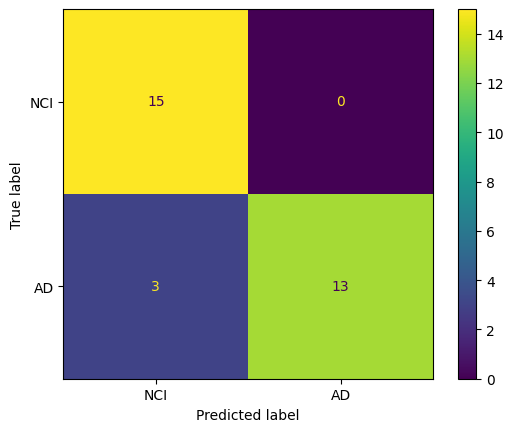

In [319]:
import seaborn as sns
import matplotlib.pyplot as plt
conf_matrix = confusion_matrix(y_test_best,y_pred)

disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['NCI','AD'])
disp.plot()
plt.show()

In [320]:
count_matrix_raw

,ENSG00000115282,ENSG00000239305,ENSG00000174827,ENSG00000256422,ENSG00000066933,ENSG00000108379,ENSG00000174437,ENSG00000078304,ENSG00000101443,ENSG00000204217,...,ENSG00000165591,ENSG00000113532,ENSG00000151892,ENSG00000102100,ENSG00000279765,ENSG00000103657,ENSG00000011105,ENSG00000129515,ENSG00000214174,ENSG00000235944
specimenID,,,,,,,,,,,,,,,,,,,,,
23_120411,305,451,28,36,1313,344,7045,1718,140,1371,...,26,82,524,274,14,2669,618,472,491,270
591_120522,323,709,35,45,2103,414,8685,2581,199,2176,...,50,129,499,367,40,3430,762,712,702,372
691_120605,381,638,33,49,2041,362,7019,2565,187,1894,...,58,112,566,302,27,3110,741,699,751,262
943_131101,478,910,31,47,871,267,9549,3617,153,3257,...,76,194,1544,454,20,3968,670,986,1401,188
588_120522,280,624,31,38,1760,324,8138,2377,124,1873,...,48,104,708,296,35,3585,655,523,606,260
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,165,275,16,13,768,87,3075,1159,45,914,...,16,53,438,126,32,1204,336,392,259,125
142_120419,186,412,23,15,1279,173,6775,1962,57,1536,...,18,81,229,288,18,2590,331,431,536,177
120_120418,267,444,44,22,1429,100,3030,1472,87,1076,...,29,66,464,186,58,1849,558,655,498,294


In [321]:
clinical_data_AD_NCI = clinical_data_AD_NCI.loc[count_matrix_raw.index]

In [322]:
clinical_data_AD_NCI['Label'] = clinical_data_AD_NCI.Category.apply(return_AD_label)
clinical_data_AD_NCI['Label'] .value_counts()

Label
1    110
0     78
Name: count, dtype: int64

In [323]:
from tqdm import tqdm
accuracies = []
#random_state= 42

X=count_matrix_raw
    

y= clinical_data_AD_NCI['Label']
acc = 0
neg_acc = 1
for i in range(100):
    X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    model = LogisticRegression(max_iter=10000, solver='liblinear', random_state=42, class_weight={1:1.42})
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    if accuracy > acc:
        acc = accuracy
        model_best = model
        X_train_best = X_train_scaled
        X_test_best = X_test_scaled
        y_test_best = y_test
        train_index = X_train.index.tolist()
    if accuracy < neg_acc:
        neg_acc= accuracy
        train_index_neg = X_train.index.tolist()
    print('Overall Accuracy:', accuracy)
    print('Postive Accuracy: ',recall_score(y_test,y_pred, pos_label = 0))
    print('Negative Accuracy: ', recall_score(y_test,y_pred, pos_label = 1))  

Overall Accuracy: 0.7368421052631579
Postive Accuracy:  0.65
Negative Accuracy:  0.8333333333333334
Overall Accuracy: 0.7631578947368421
Postive Accuracy:  0.5882352941176471
Negative Accuracy:  0.9047619047619048
Overall Accuracy: 0.6578947368421053
Postive Accuracy:  0.8
Negative Accuracy:  0.5652173913043478
Overall Accuracy: 0.6052631578947368
Postive Accuracy:  0.5882352941176471
Negative Accuracy:  0.6190476190476191
Overall Accuracy: 0.6842105263157895
Postive Accuracy:  0.6666666666666666
Negative Accuracy:  0.7
Overall Accuracy: 0.6842105263157895
Postive Accuracy:  0.6
Negative Accuracy:  0.7391304347826086
Overall Accuracy: 0.6842105263157895
Postive Accuracy:  0.7368421052631579
Negative Accuracy:  0.631578947368421
Overall Accuracy: 0.7105263157894737
Postive Accuracy:  0.6875
Negative Accuracy:  0.7272727272727273
Overall Accuracy: 0.8157894736842105
Postive Accuracy:  0.7894736842105263
Negative Accuracy:  0.8421052631578947
Overall Accuracy: 0.7368421052631579
Postive A

In [324]:
y_pred = model_best.predict(X_test_best)
accuracy = accuracy_score(y_test_best, y_pred)
print('Overall Accuracy:', accuracy)
print('Postive Accuracy: ',recall_score(y_test_best,y_pred, pos_label = 0))
print('Negative Accuracy: ', recall_score(y_test_best,y_pred, pos_label = 1))

Overall Accuracy: 0.868421052631579
Postive Accuracy:  0.8235294117647058
Negative Accuracy:  0.9047619047619048


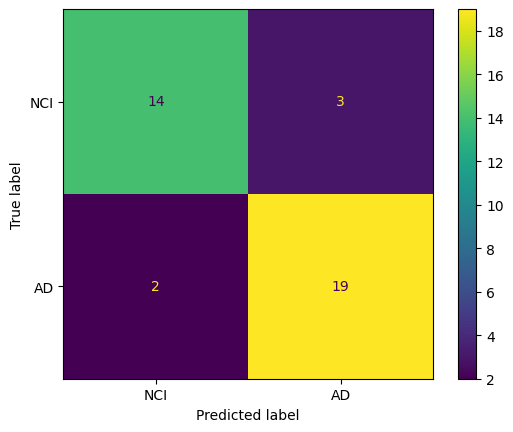

In [325]:
import seaborn as sns
import matplotlib.pyplot as plt
conf_matrix = confusion_matrix(y_test_best,y_pred)

disp = ConfusionMatrixDisplay(conf_matrix, display_labels=['NCI','AD'])
disp.plot()
plt.show()

In [326]:
final_count_matrix

,ENSG00000101901,ENSG00000174839,ENSG00000151466,ENSG00000168288,ENSG00000112343,ENSG00000172890,ENSG00000150991,ENSG00000100029,ENSG00000181894,ENSG00000206560,...,ENSG00000039560,ENSG00000223496,ENSG00000166681,ENSG00000078061,ENSG00000272143,ENSG00000120457,ENSG00000100528,ENSG00000116205,ENSG00000100603,ENSG00000114933
23_120411,434,392,216,290,130,755,3276,582,302,692,...,136,1598,5131,363,50,49,662,411,530,366
591_120522,497,392,268,432,157,844,6423,777,520,876,...,191,2719,7720,411,47,28,906,508,648,451
691_120605,530,484,252,508,200,1171,8300,947,525,1047,...,167,2728,9469,566,74,100,1186,504,724,470
588_120522,367,428,233,326,130,1129,6307,738,374,821,...,134,2097,4785,513,91,17,710,406,587,365
604_120523,575,485,410,600,146,1065,8918,1122,551,1289,...,223,3768,12588,525,67,68,1104,560,918,540
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,345,315,186,319,141,638,4550,554,274,576,...,149,1529,4705,359,38,14,677,338,451,261
142_120419,280,260,167,265,125,601,4328,515,324,669,...,153,1104,5357,336,28,48,552,379,392,254
120_120418,404,417,259,282,198,1045,4818,833,359,830,...,206,2261,5185,399,50,27,675,507,626,408
483_120515,547,324,206,486,127,949,7626,971,591,994,...,144,3253,7818,382,37,48,1153,521,627,403


In [327]:
final_count_matrix.T.head() # input of conorm package 

,23_120411,591_120522,691_120605,588_120522,604_120523,545_120516,364_120502,705_120605,711_120531,602_120523,...,65_120417,628_120524,587_120522,283_120430,721_120531,677_120604,142_120419,120_120418,483_120515,174_120424
ENSG00000101901,434,497,530,367,575,227,381,278,348,615,...,225,209,301,314,298,345,280,404,547,421
ENSG00000174839,392,392,484,428,485,287,396,333,327,534,...,250,246,289,252,231,315,260,417,324,448
ENSG00000151466,216,268,252,233,410,206,259,199,224,290,...,226,138,181,217,143,186,167,259,206,278
ENSG00000168288,290,432,508,326,600,236,330,355,387,579,...,257,215,200,313,242,319,265,282,486,378
ENSG00000112343,130,157,200,130,146,121,106,103,129,187,...,51,80,79,54,122,141,125,198,127,357


In [328]:
# https://pypi.org/project/conorm/

final_count_matrix = conorm.mrn(final_count_matrix.T)
final_count_matrix

,23_120411,591_120522,691_120605,588_120522,604_120523,545_120516,364_120502,705_120605,711_120531,602_120523,...,65_120417,628_120524,587_120522,283_120430,721_120531,677_120604,142_120419,120_120418,483_120515,174_120424
ENSG00000101901,483.749233,428.287142,393.796510,348.370890,392.736981,315.365572,376.066735,301.448336,392.819935,409.181322,...,296.573693,299.072257,372.140831,354.778728,417.815236,435.136655,359.696638,387.165725,454.480361,377.965207
ENSG00000174839,436.934791,337.803943,359.617945,406.274499,331.265105,398.722111,390.872512,361.087396,369.115284,355.289148,...,329.526326,352.018064,357.304652,284.726877,323.876911,397.298685,334.004021,399.624028,269.198605,402.205256
ENSG00000151466,240.759987,230.947593,187.239095,221.172800,280.038543,286.190784,255.646415,215.784960,252.849614,192.947290,...,297.891798,197.473548,223.779038,245.181478,200.495231,234.595414,214.533352,248.207730,171.157138,249.582726
ENSG00000168288,323.242575,372.273733,377.450240,309.452072,409.812501,327.869053,325.727093,384.943019,436.842859,385.229245,...,338.753063,307.658064,247.269655,353.648860,339.299622,402.343748,340.427175,270.249343,403.797907,339.360685
ENSG00000112343,144.901844,135.293926,148.602457,123.401133,99.721042,168.102354,104.627490,111.687693,145.614286,124.417735,...,67.223370,114.477419,97.671514,61.012902,171.051875,177.838459,160.578856,189.749539,105.519206,320.507313
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSG00000120457,54.616849,24.128853,74.301228,16.137071,46.445417,87.524366,23.689243,42.289515,29.348616,52.561503,...,27.680211,15.740645,17.308876,12.428554,29.443356,17.657719,61.662281,25.874937,39.881275,30.524506
ENSG00000100528,737.884775,780.740745,881.212568,673.960033,754.055003,608.502734,704.754983,720.006098,965.117945,926.146992,...,821.179603,891.492901,829.589694,767.180753,601.485693,853.876857,709.116230,646.873427,957.981455,716.428112
ENSG00000116205,458.112753,437.766334,374.478191,385.391230,382.491668,343.151085,419.497014,391.449098,516.987156,351.297135,...,369.069485,367.758709,589.738128,347.999517,487.918464,426.307796,486.875092,485.873818,432.878003,495.574333
ENSG00000100603,590.753672,558.410599,537.940893,557.203577,627.013127,594.609978,548.800799,590.968861,574.555595,544.244425,...,536.468858,569.525160,485.884873,595.440732,615.506338,568.830816,503.575293,599.915208,520.949152,565.601141


In [329]:
final_count_matrix = final_count_matrix.T
final_count_matrix

,ENSG00000101901,ENSG00000174839,ENSG00000151466,ENSG00000168288,ENSG00000112343,ENSG00000172890,ENSG00000150991,ENSG00000100029,ENSG00000181894,ENSG00000206560,...,ENSG00000039560,ENSG00000223496,ENSG00000166681,ENSG00000078061,ENSG00000272143,ENSG00000120457,ENSG00000100528,ENSG00000116205,ENSG00000100603,ENSG00000114933
23_120411,483.749233,436.934791,240.759987,323.242575,144.901844,841.545325,3651.526471,648.714410,336.618130,771.323662,...,151.589621,1781.178052,5719.164322,404.610534,55.731478,54.616849,737.884775,458.112753,590.753672,407.954423
591_120522,428.287142,337.803943,230.947593,372.273733,135.293926,727.312570,5534.986540,669.575672,448.107271,754.888402,...,164.593248,2343.083980,6652.669483,354.177093,40.502003,24.128853,780.740745,437.766334,558.410599,388.646883
691_120605,393.796510,359.617945,187.239095,377.450240,148.602457,870.067384,6167.001950,703.632632,390.081449,777.933860,...,124.083051,2026.937508,7035.583309,420.544952,54.982909,74.301228,881.212568,374.478191,537.940893,349.215773
588_120522,348.370890,406.274499,221.172800,309.452072,123.401133,1071.691377,5986.853423,700.538739,355.015567,779.325616,...,127.198091,1990.555197,4542.110929,486.959855,86.380793,16.137071,673.960033,385.391230,557.203577,346.472412
604_120523,392.736981,331.265105,280.038543,409.812501,99.721042,727.417190,6091.179814,766.349378,376.344481,880.413857,...,152.313646,2573.622509,8597.866281,358.585939,45.762396,46.445417,754.055003,382.491668,627.013127,368.831251
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
677_120604,435.136655,397.298685,234.595414,402.343748,177.838459,804.687496,5738.758790,698.741180,345.586793,726.489025,...,187.928585,1928.475206,5934.254968,452.794375,47.928095,17.657719,853.876857,426.307796,568.830816,329.190339
142_120419,359.696638,334.004021,214.533352,340.427175,160.578856,772.063141,5559.882322,661.584888,416.220396,859.418039,...,196.548520,1418.232459,6881.767467,431.635966,35.969664,61.662281,709.116230,486.875092,503.575293,326.296236
120_120418,387.165725,399.624028,248.207730,270.249343,189.749539,1001.455898,4617.238772,798.289725,344.040830,795.414732,...,197.416187,2166.786397,4968.946250,382.374070,47.916550,25.874937,646.873427,485.873818,599.915208,390.999049
483_120515,454.480361,269.198605,171.157138,403.797907,105.519206,788.486037,6336.137532,806.764955,491.038196,825.874732,...,119.643824,2702.787227,6495.662632,317.388479,30.741816,39.881275,957.981455,432.878003,520.949152,334.836536


In [330]:
final_count_matrix.to_csv('./data_preprocessed/count_matrix_preprocessed/final_count_matrix_mrn_normalized_for_grn.csv')